# RSS Change for a Given Gamma

Examines how the RSS of packets changes while the angle the transmitter faces when it transmits those packets remains constant.

For the `Range Trials/` experiments, the tag didn't move at all, meaning there should be very little change.

In [1]:
from BleFinley import *
from ble_logs import BleLogStatic

tx_a = Transmitter('a', -1.448596, 53.368606, 131.0 + 1.5)
tx_b = Transmitter('b', -1.448626, 53.367865, 131.0 + 1.5)
tx_c = Transmitter('c', -1.450168, 53.368359, 122.0 + 1.5)
tx_e = Transmitter('e', -1.449990, 53.369204, 118.0 + 1.5)

In [2]:
from matplotlib import pyplot as plt

def rss_diff_at_gamma(ble_log :BleLog, gamma :float, packet_gap = 1) -> list[int]:
    rss_at_gamma = ble_log.all_rss_at_gamma(gamma)
    rss_differences = []

    for x in range(len(rss_at_gamma) - packet_gap):
        rss_differences.append(rss_at_gamma[x] - rss_at_gamma[x + packet_gap])

    return rss_differences

## Examine Range Trial 7

Look at the difference in RSS just for gamma = 0, and then look at a combined histogram of all angles from 0-360 degrees.

BleLog | tx: c, no.packets: 1533, time: 86.140s


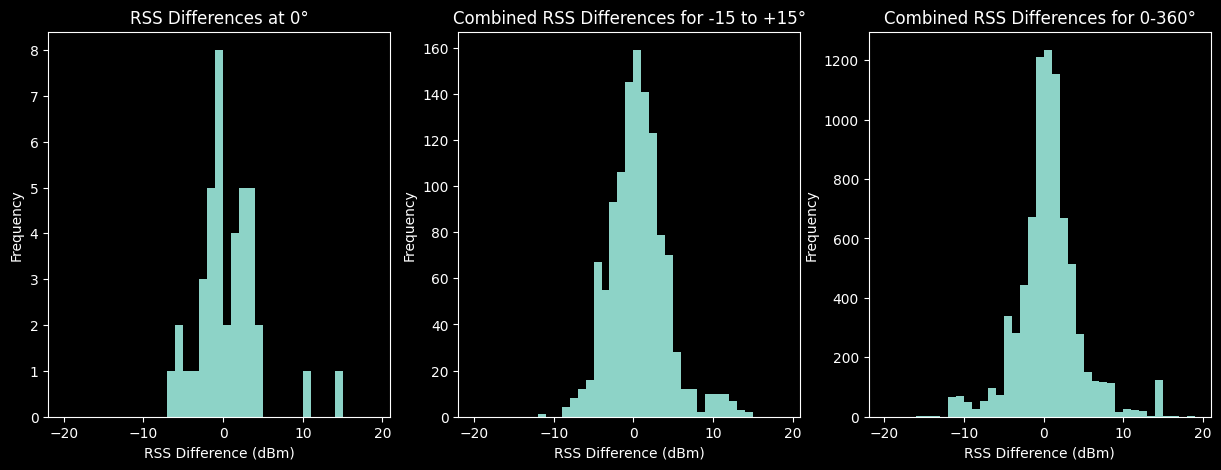

In [3]:
import numpy as np

range_7_log = BleLog("/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/Range Trials/7.log", tx_c, None)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("RSS Differences at 0°")
plt.ylabel("Frequency")
plt.xlabel("RSS Difference (dBm)")
plt.hist(rss_diff_at_gamma(range_7_log, 0), bins=np.arange(-20, 20))

plt.subplot(1, 3, 2)
diffs = []

for degree in range(-15, 15):
    diffs.extend(rss_diff_at_gamma(range_7_log, degree))

plt.hist(diffs, bins=np.arange(-20, 20))
plt.title(f"Combined RSS Differences for -15 to +15°")
plt.ylabel("Frequency")
plt.xlabel("RSS Difference (dBm)")

plt.subplot(1, 3, 3)
diffs = []

for degree in range(0, 359):
    diffs.extend(rss_diff_at_gamma(range_7_log, degree))

plt.hist(diffs, bins=np.arange(-20, 20))
plt.title("Combined RSS Differences for 0-360°")
plt.ylabel("Frequency")
plt.xlabel("RSS Difference (dBm)")
plt.show()

## Examine All Range Trials Together

For all the range trials in `/bluetooth_experiments/March 26 2025 Field Trial/Range Trials/`, examine the difference in RSS between two packets (sequential or with a large gap between them) for a given gamma. Collate this information into blocks of 30 degrees and then combine the data for all angles. The values of gamma for each packet are normalised so 0 degrees is pointing directly at the bee tag.

In [4]:
# parse all range trials into a dictionary
range_logs :dict[str, BleLog] = {}
range_trial_folder = "/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/Range Trials/"

range_logs["1.log"] = BleLogStatic(range_trial_folder + "1.log", tx_c, -1.449861, 53.368415, 128.1)
range_logs["2.log"] = BleLogStatic(range_trial_folder + "2.log", tx_c, -1.449851, 53.368798, 124.3)
range_logs["3.log"] = BleLogStatic(range_trial_folder + "3.log", tx_c, -1.449712, 53.369261, 111.0)
range_logs["4.log"] = BleLogStatic(range_trial_folder + "4.log", tx_c, -1.449732, 53.369659, 123.5)
range_logs["5.log"] = BleLogStatic(range_trial_folder + "5.log", tx_c, -1.449705, 53.369932, 112.0)
range_logs["6.log"] = BleLogStatic(range_trial_folder + "6.log", tx_c, -1.449617, 53.370239, 111.2)
range_logs["7.log"] = BleLogStatic(range_trial_folder + "7.log", tx_c, -1.449647, 53.370649, 106.6)
range_logs["8.log"] = BleLogStatic(range_trial_folder + "8.log", tx_c, -1.449575, 53.371191, 104.9)
range_logs["9.log"] = BleLogStatic(range_trial_folder + "9.log", tx_c, -1.449595, 53.371545, 107.7)

BleLog | tx: c, no.packets: 8314, time: 86.369s
BleLogStatic | angle offset: -74.055
BleLog | tx: c, no.packets: 3108, time: 75.356s
BleLogStatic | angle offset: -23.199
BleLog | tx: c, no.packets: 3208, time: 89.925s
BleLogStatic | angle offset: -16.699
BleLog | tx: c, no.packets: 6502, time: 87.054s
BleLogStatic | angle offset: -10.929
BleLog | tx: c, no.packets: 1518, time: 91.795s
BleLogStatic | angle offset: -9.728
BleLog | tx: c, no.packets: 93, time: 71.421s
BleLogStatic | angle offset: -9.507
BleLog | tx: c, no.packets: 1533, time: 86.140s
BleLogStatic | angle offset: -7.374
BleLog | tx: c, no.packets: 1536, time: 96.692s
BleLogStatic | angle offset: -6.699
BleLog | tx: c, no.packets: 2864, time: 73.173s
BleLogStatic | angle offset: -5.807


In [45]:
from IPython.display import display, Markdown
from scipy.stats import norm, cauchy, laplace

def range_trial_rss_diffs_in_blocks(range_trials, packet_gap = 1, log = False):
    for start_angle in range (-15, 360 - 15, 30):
        display(Markdown(f"#### {start_angle} to {(start_angle + 30) % 360} Degrees"))
        plt.figure(figsize=(27, 5))
        graph_num = 1
        combined_diffs = []

        for name, ble_log in range_trials.items():
            diffs = []

            for angle in range(start_angle, start_angle + 29):
                diffs.extend(rss_diff_at_gamma(ble_log, angle, packet_gap))

            combined_diffs.extend(diffs)

            plt.subplot(1, 10, graph_num)
            plt.hist(diffs, bins=np.arange(-20, 20))
            plt.yscale("log") if log else None
            plt.title(name)
            graph_num += 1

        # draw combined graph with a laplace & normal mix distribution
        plt.subplot(1, 10, graph_num)
        plt.hist(combined_diffs, bins=np.arange(-20, 20), density=True)
        x_values = np.linspace(-20, 20, 240)

        mix = 0.351 * norm.pdf(x_values, 0, 3.464) + 0.649 * laplace.pdf(x_values, 0, 3.139)
        plt.plot(x_values, mix)

        plt.yscale("log") if log else None
        plt.title("Combined")
        ax = plt.gca()
        ax.set_facecolor("#5E1414")
        plt.show()

def combined_rss_at_gamma_analysis(range_dict, packet_gap):
    range_rss_diffs = []

    for range_log in range_dict.values():
        for degree in range(0, 360 - 1):
            range_rss_diffs.extend(rss_diff_at_gamma(range_log, degree, packet_gap))

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.hist(range_rss_diffs, bins=np.arange(-20, 20))
    plt.title("All Range Trial Differences for All Angles")
    plt.ylabel("Frequency")
    plt.xlabel("RSS Difference (dBm)")

    plt.subplot(1, 3, 2)
    plt.hist(range_rss_diffs, bins=np.arange(-20, 20))
    plt.yscale("log")
    plt.title("Log of Differences for All Angles")
    plt.ylabel("Log of Frequency")
    plt.xlabel("Rss Difference (dBm)")

    # normal and cauchy distributions overlaid over data
    plt.subplot(1, 3, 3)
    plt.title("Normal & Cauchy PDF")
    x_vals = np.linspace(-20, 20, 40*2)
    plt.plot(x_vals, norm.pdf(x_vals, 0.5, 4), 'orange')
    plt.plot(x_vals, cauchy.pdf(x_vals, loc=0.5, scale=2.124), 'red')
    plt.plot(x_vals, 0.351 * norm.pdf(x_vals, 0.5, 3.464) + 0.649 * laplace.pdf(x_vals, 0.5, 3.139), 'purple')
    plt.hist(range_rss_diffs, bins=np.arange(-20, 20), density=True)
    plt.show()

    return range_rss_diffs

### Sequential Packet Differences

The difference is taken between the current packet and the packet at the same gamma in the next transmitter rotation (approximately 2 seconds later). Examine the RSS in 30 degree blocks using histograms, and then all angles combined into one histogram.

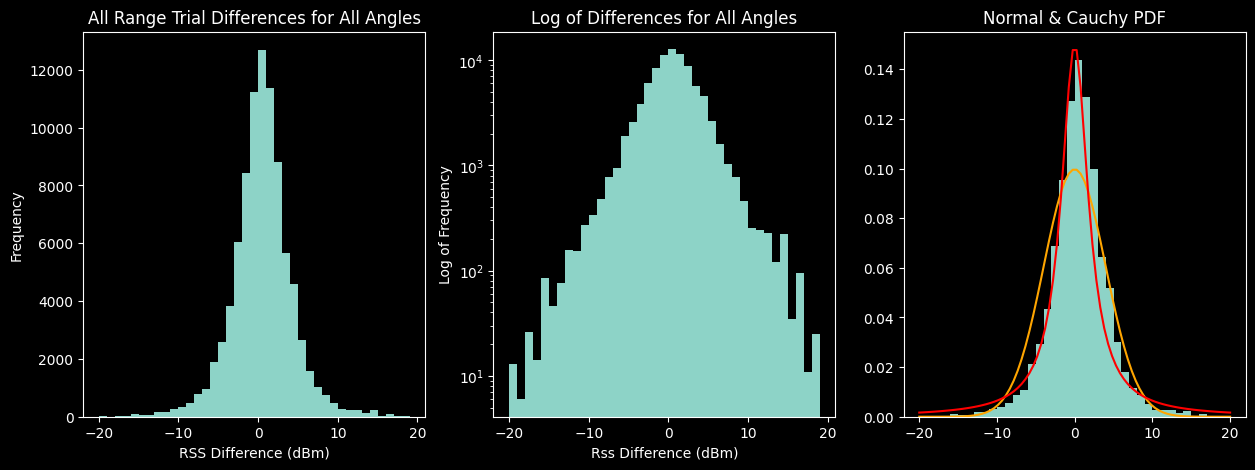

In [64]:
diffs_0 = combined_rss_at_gamma_analysis(range_logs, 1)
x_axis = np.linspace(-20, 20, 1000)

plt.show()

In [ ]:
range_trial_rss_diffs_in_blocks(range_logs)

## Two Packet Differences

This would be applicable if a sample is taken over 4 seconds

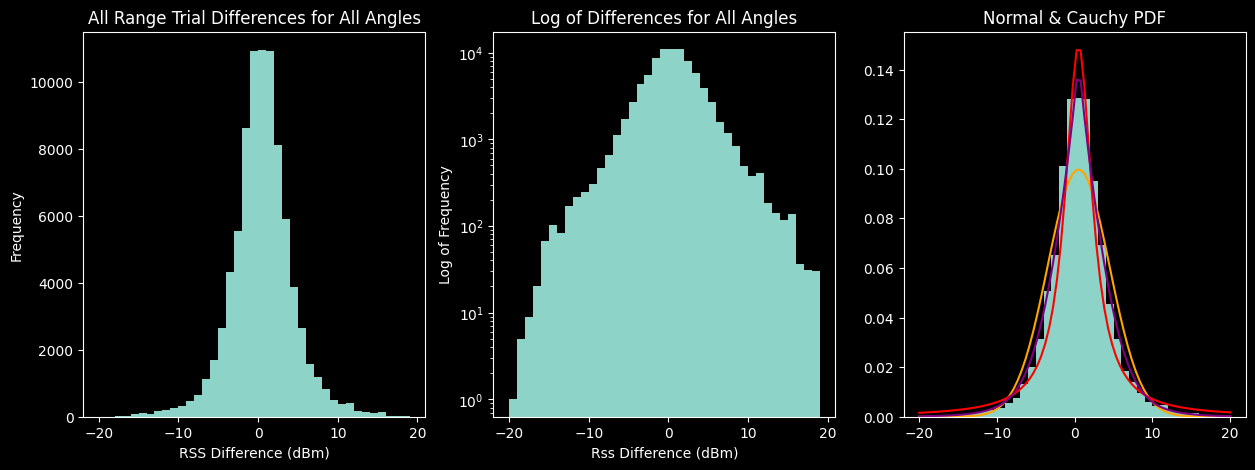

In [49]:
diffs_2 = combined_rss_at_gamma_analysis(range_logs, 2)

#### -15 to 15 Degrees

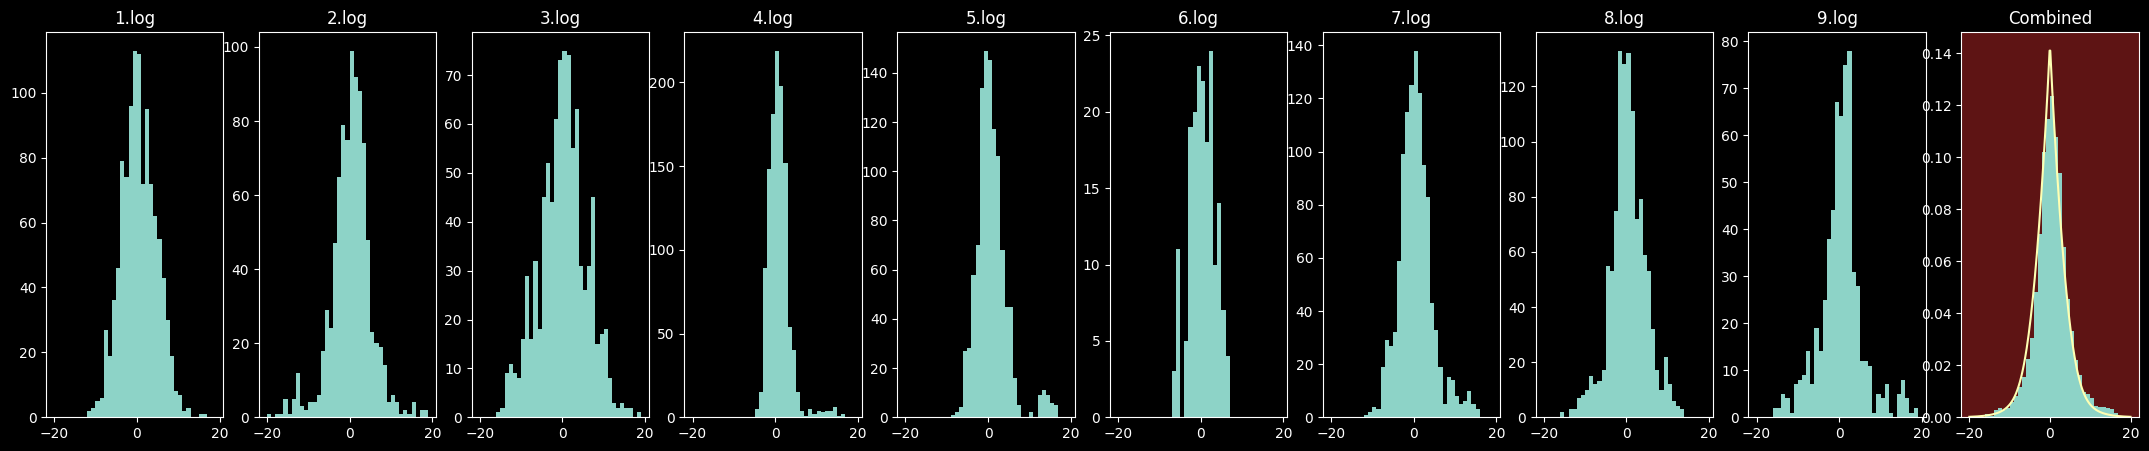

#### 15 to 45 Degrees

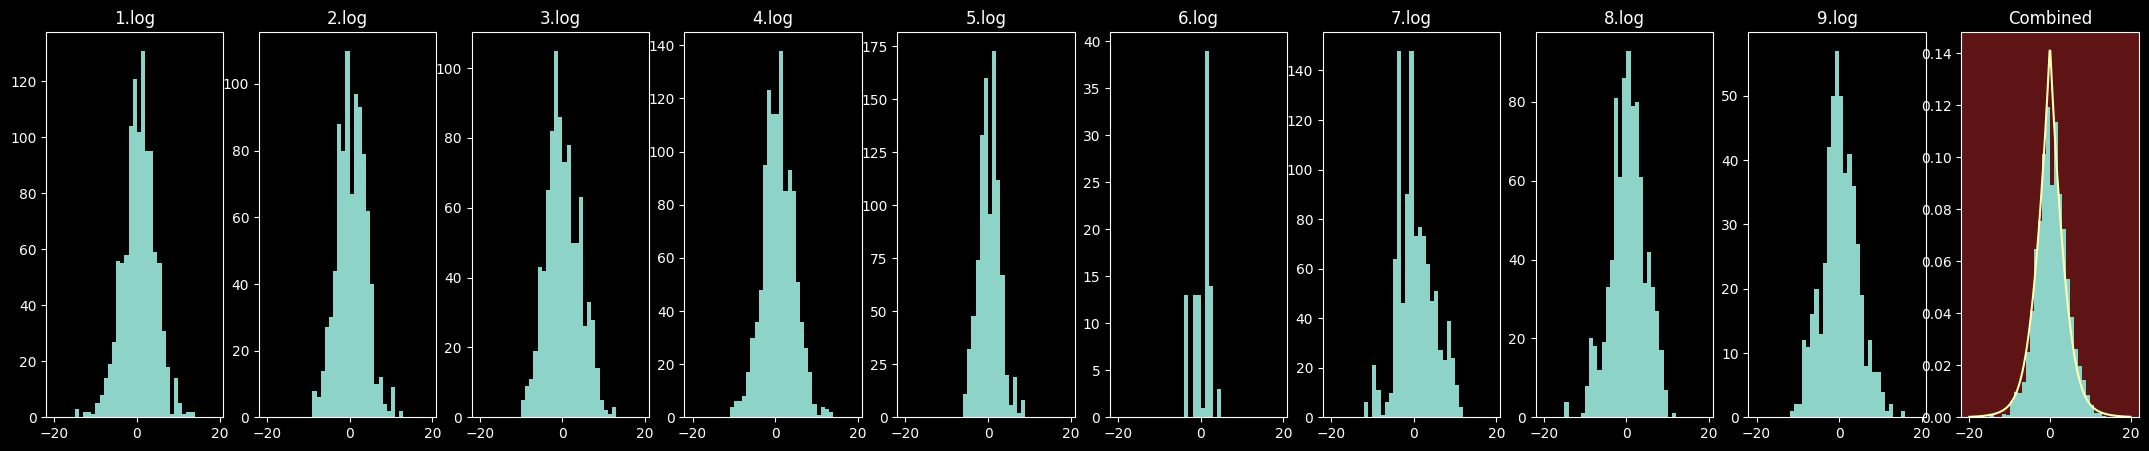

#### 45 to 75 Degrees

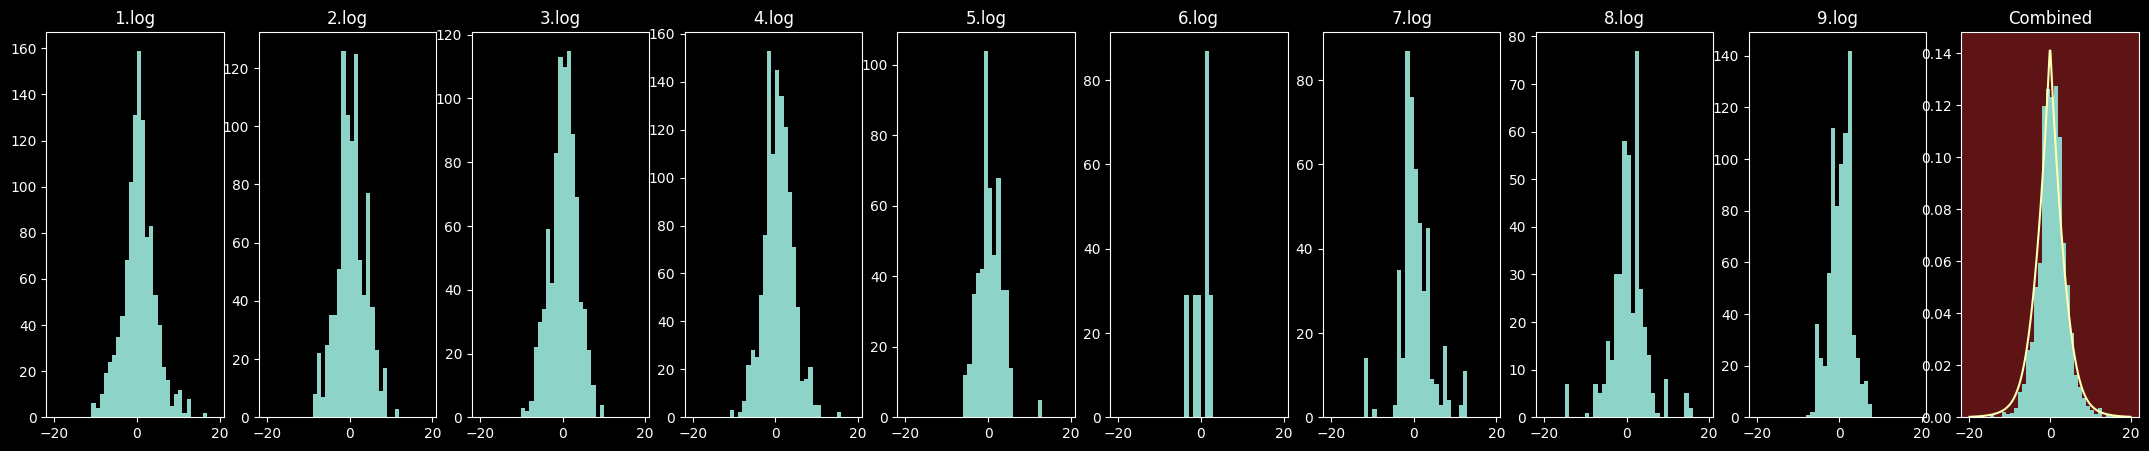

#### 75 to 105 Degrees

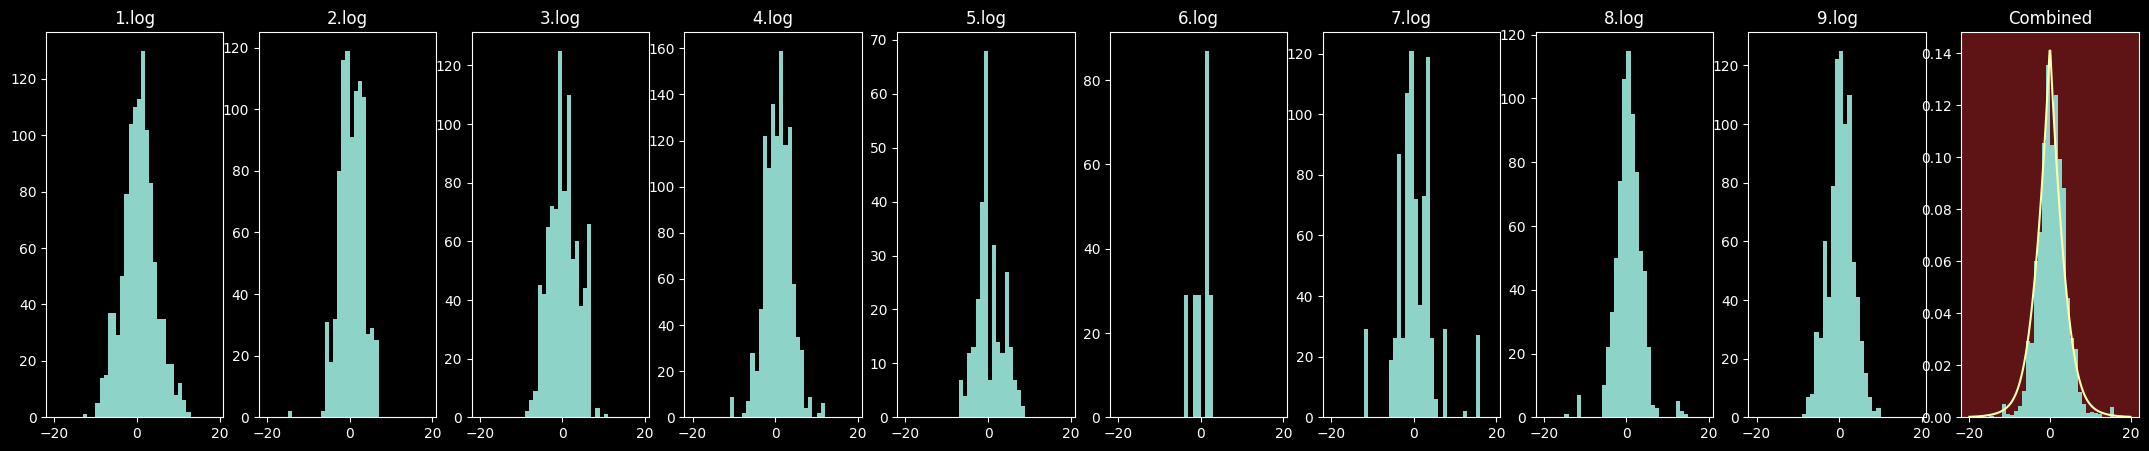

#### 105 to 135 Degrees

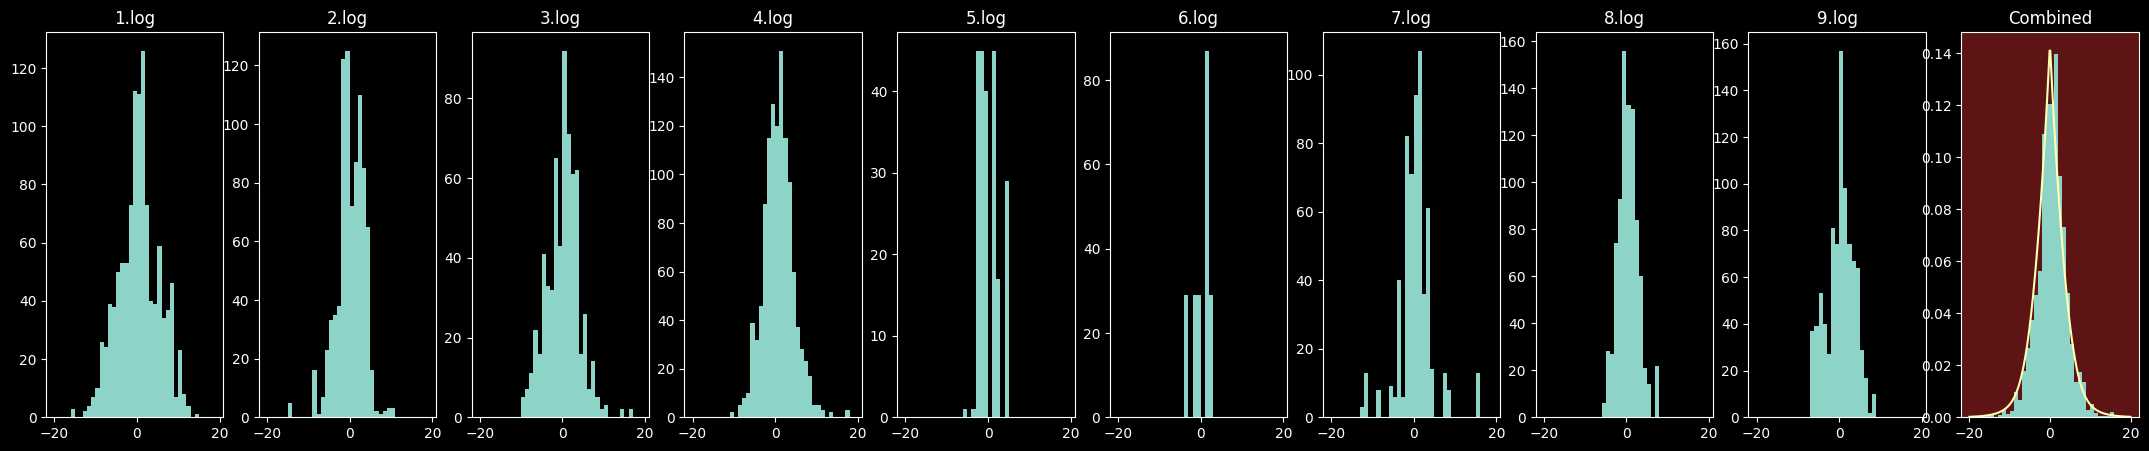

#### 135 to 165 Degrees

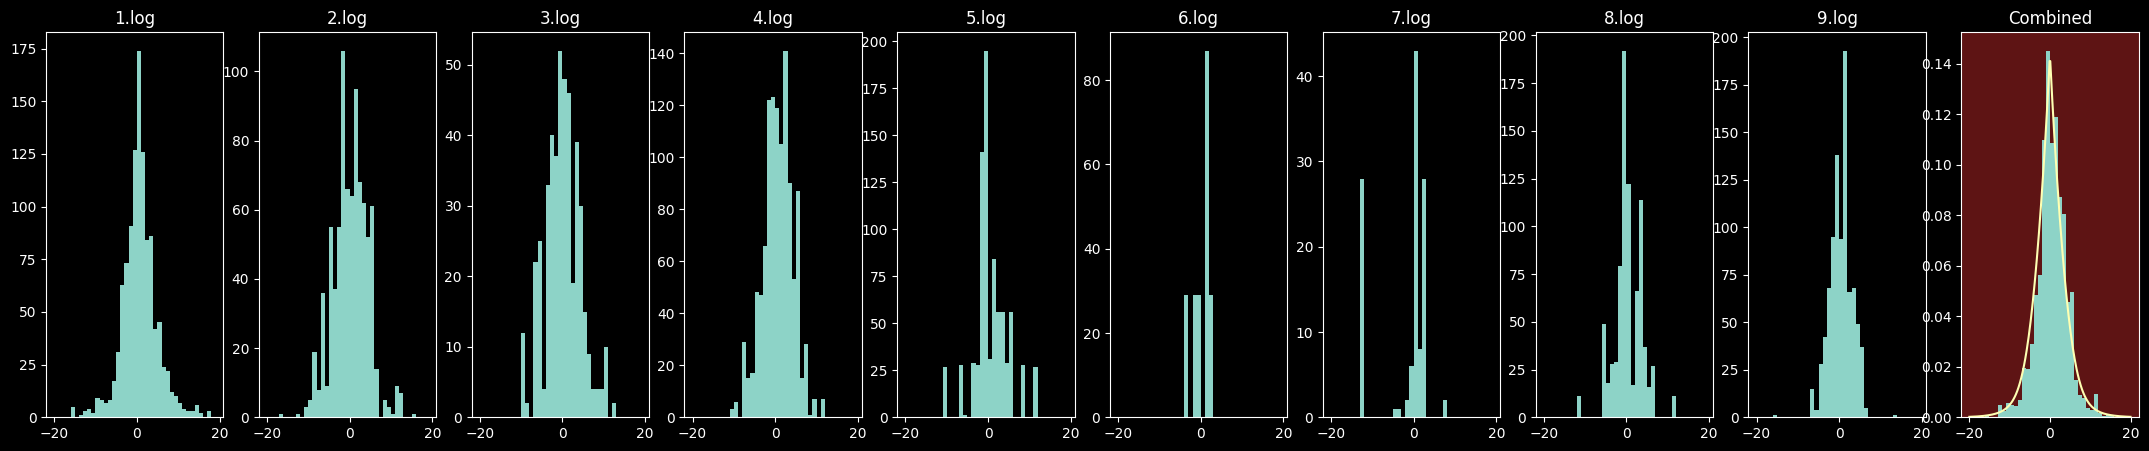

#### 165 to 195 Degrees

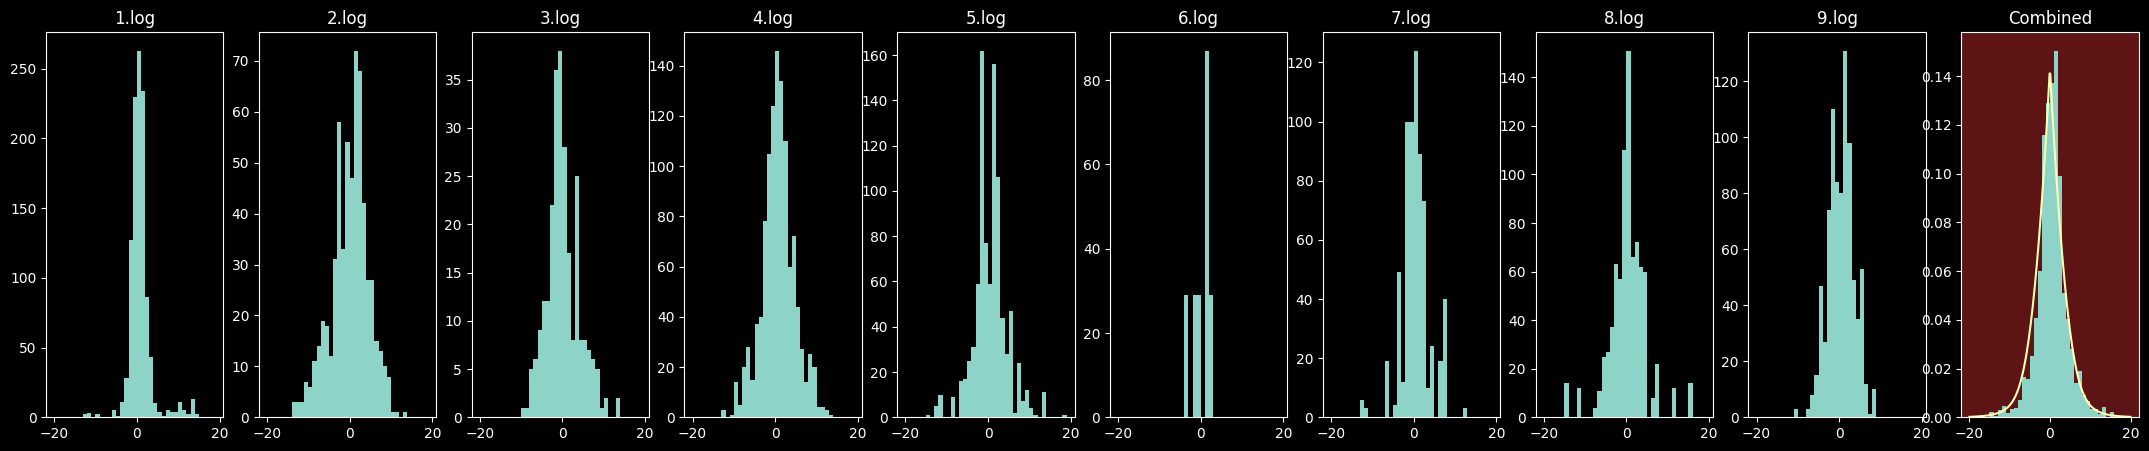

#### 195 to 225 Degrees

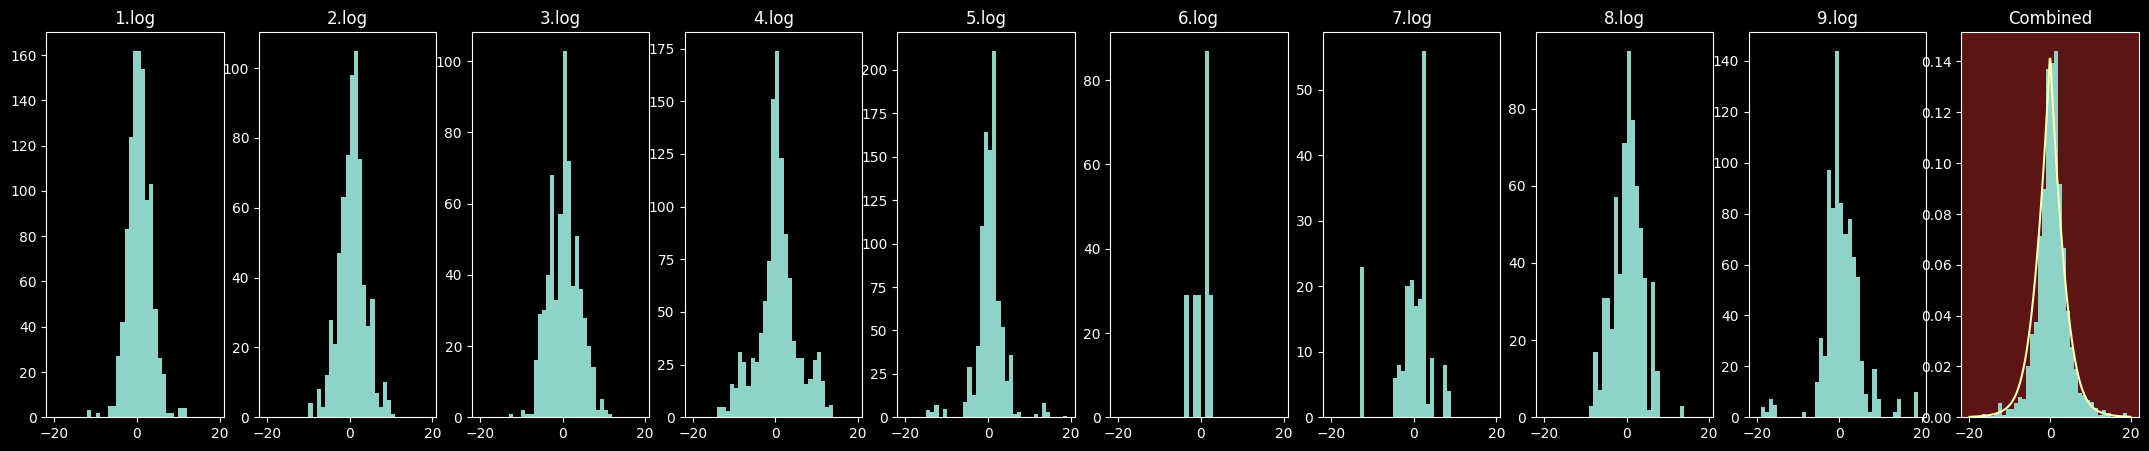

#### 225 to 255 Degrees

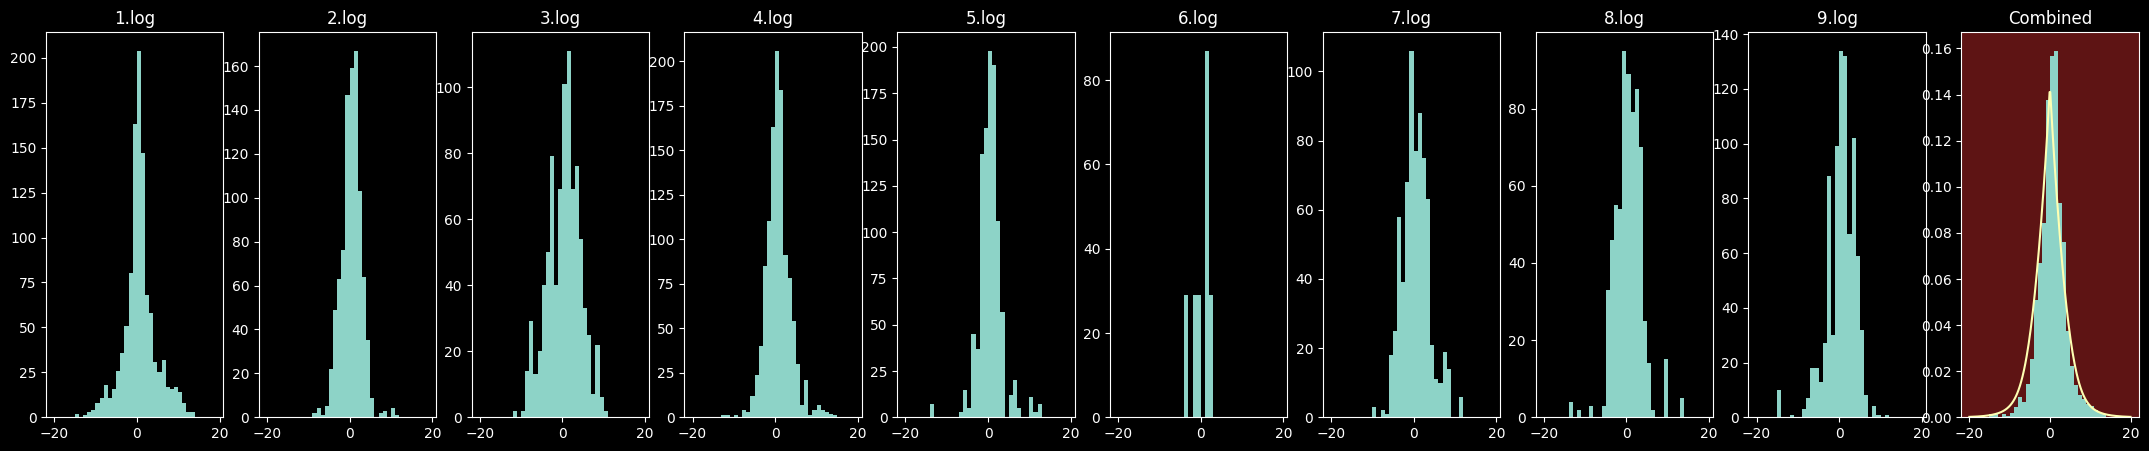

#### 255 to 285 Degrees

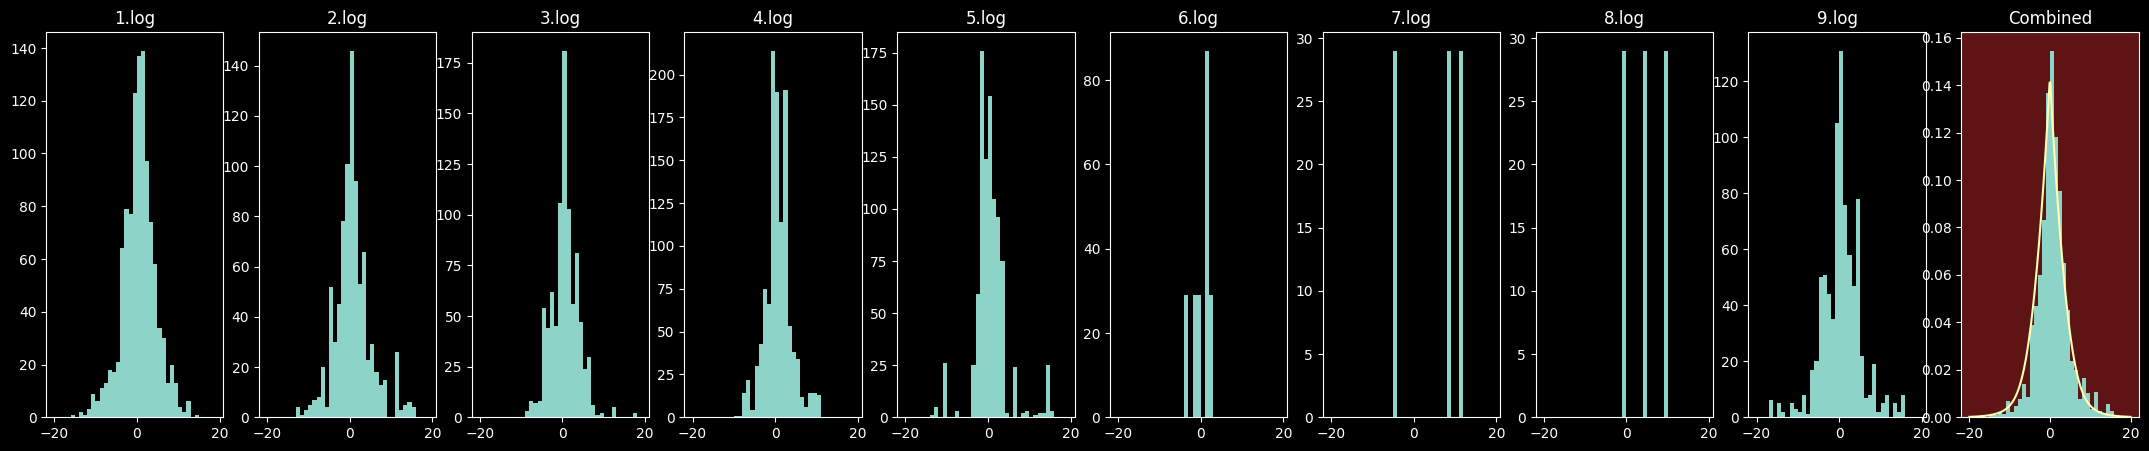

#### 285 to 315 Degrees

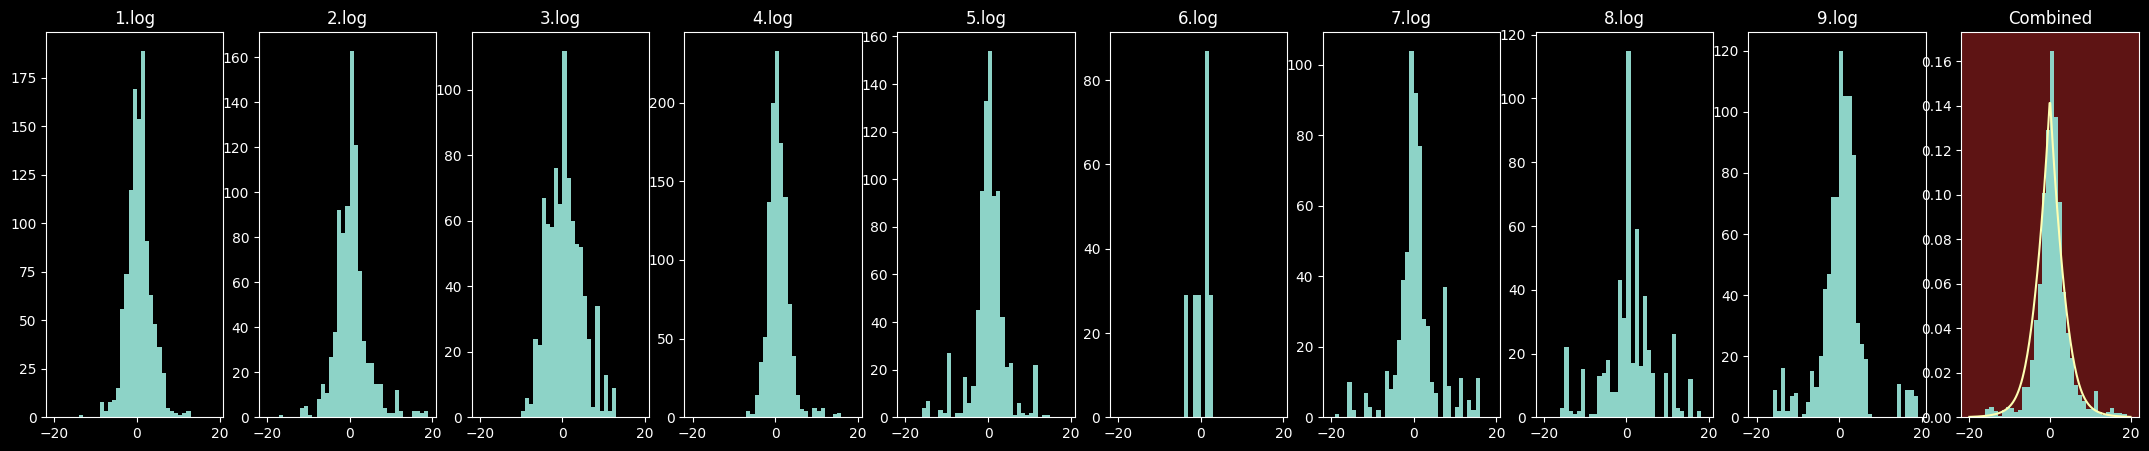

#### 315 to 345 Degrees

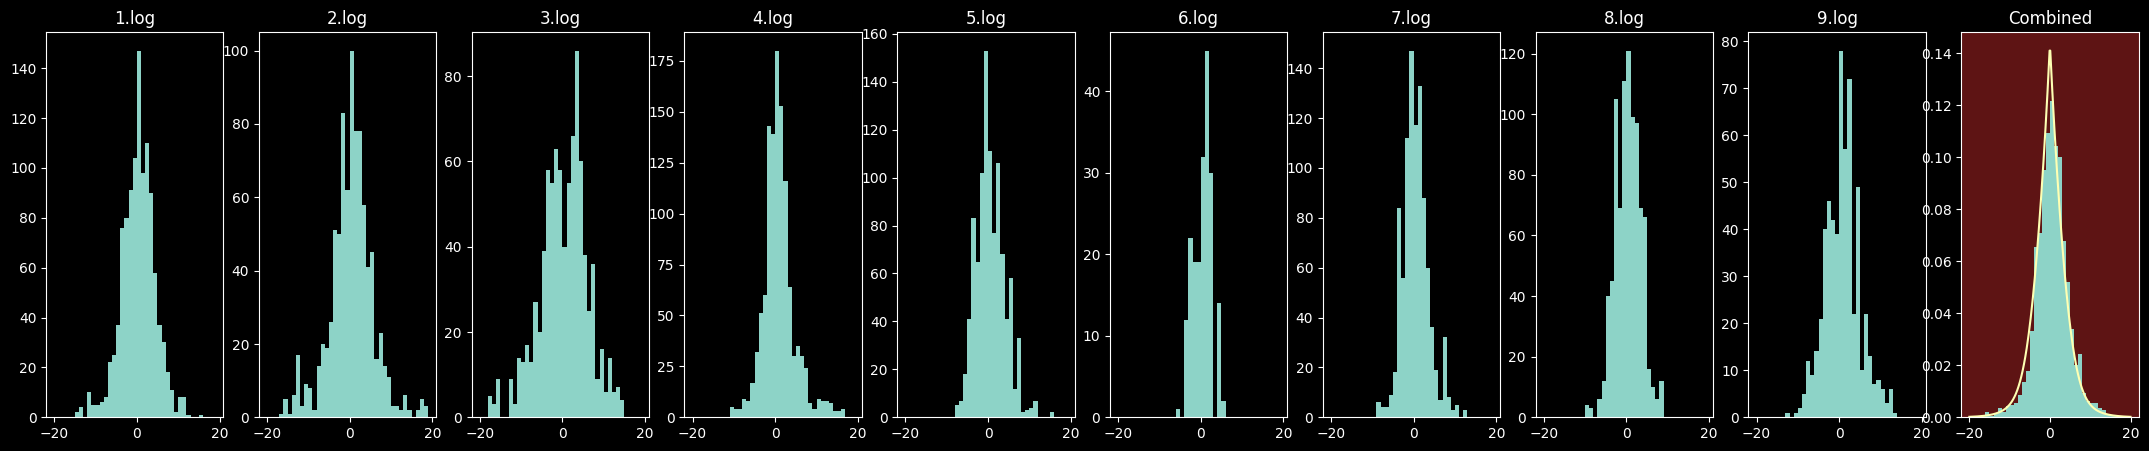

In [50]:
range_trial_rss_diffs_in_blocks(range_logs, 2)

### Five Packet Differences

The difference is taken between the current packet and the packet at the same gamma in five transmitter-rotations' time (approximately 10 seconds later). Examine the RSS in 30 degree blocks using histograms, and then all angles combined into one histogram.

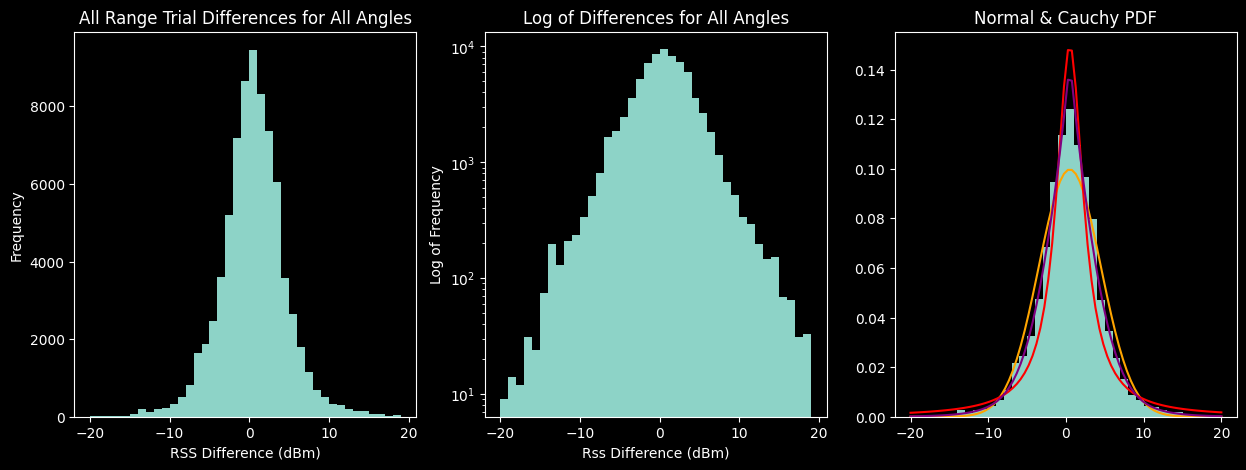

In [46]:
diffs_5 = combined_rss_at_gamma_analysis(range_logs, 5)

#### -15 to 15 Degrees

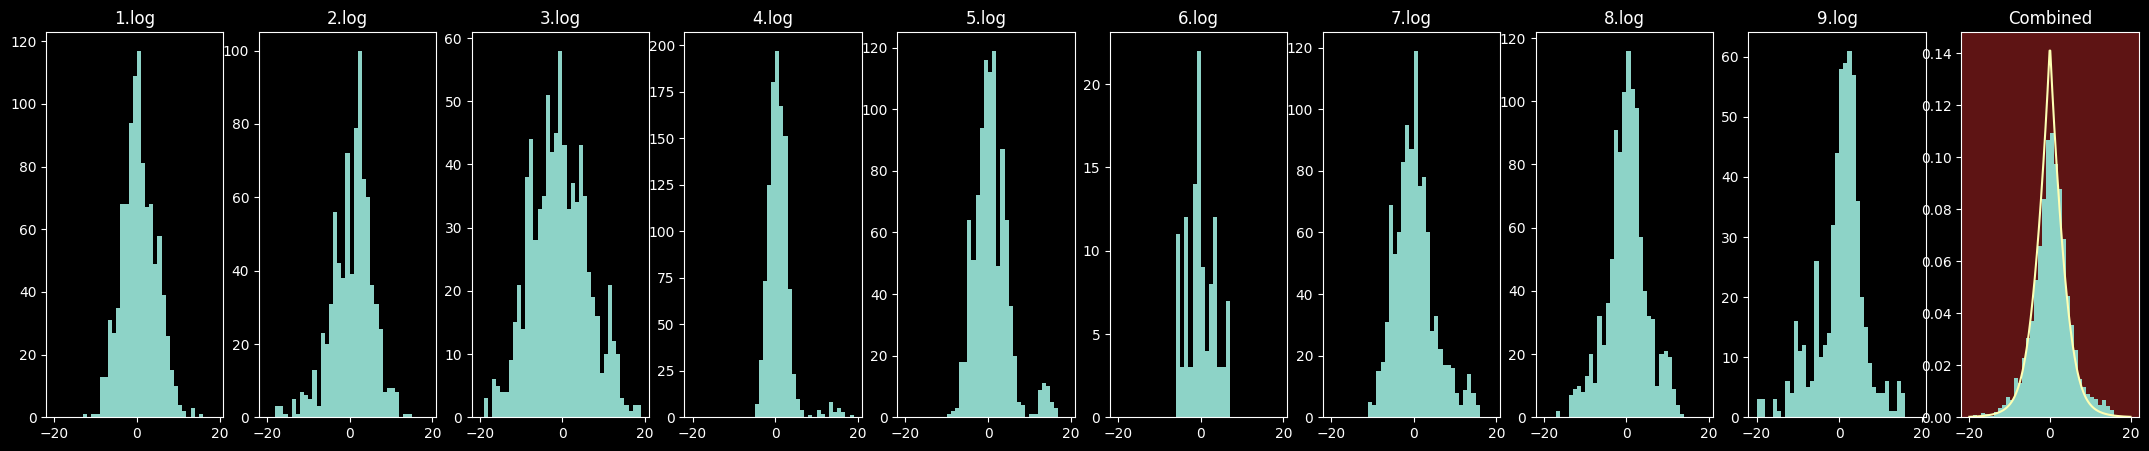

#### 15 to 45 Degrees

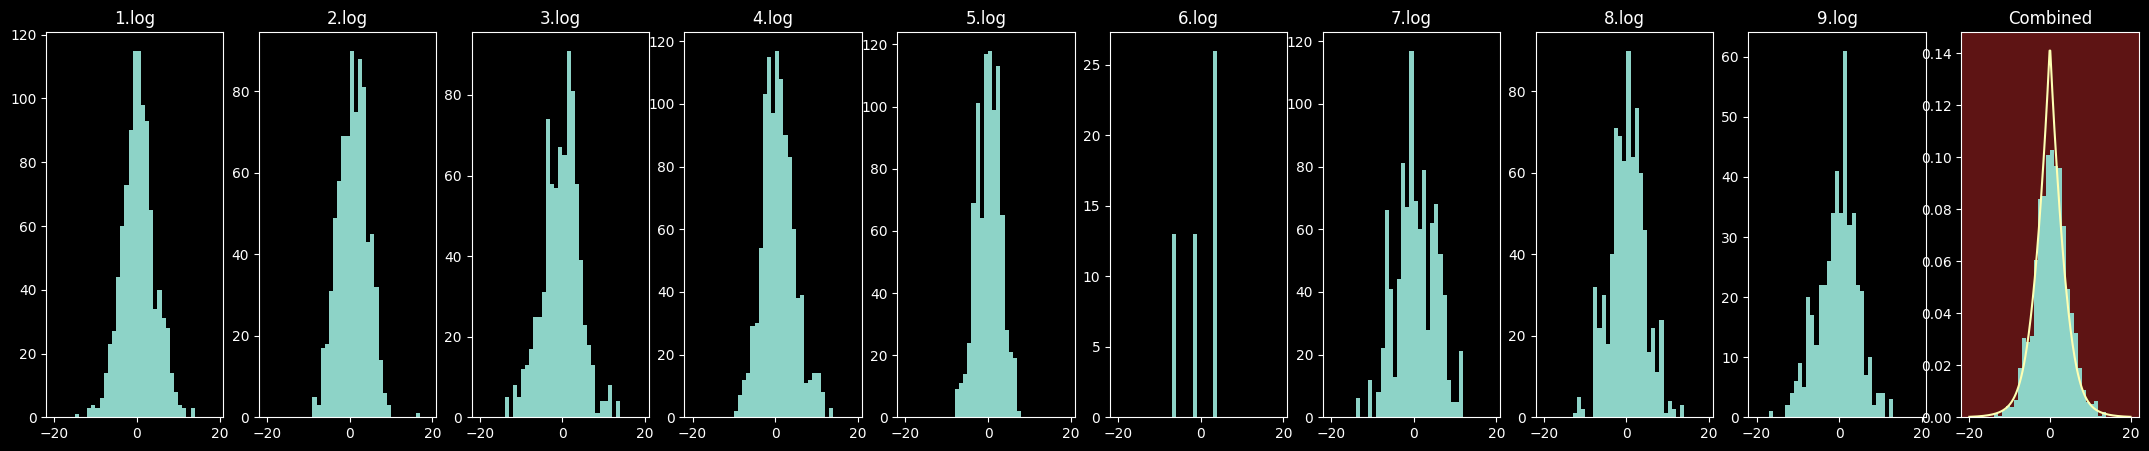

#### 45 to 75 Degrees

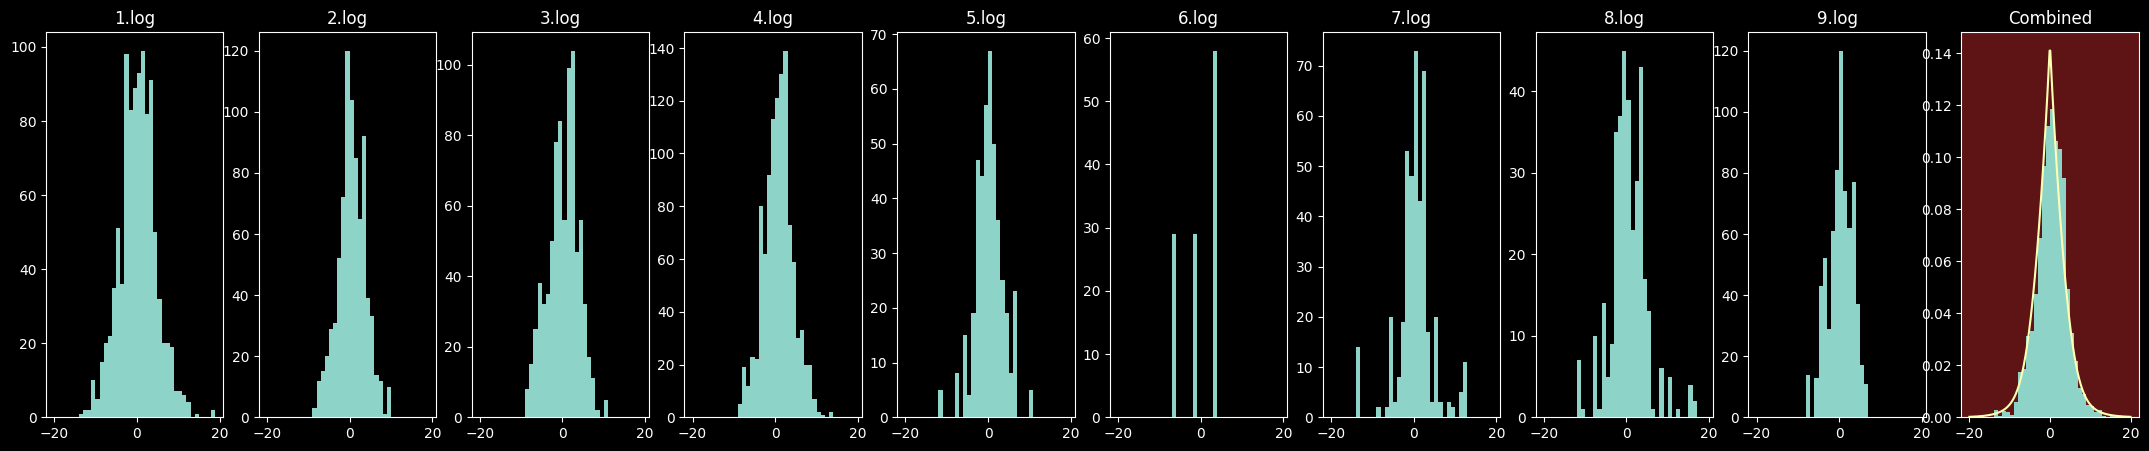

#### 75 to 105 Degrees

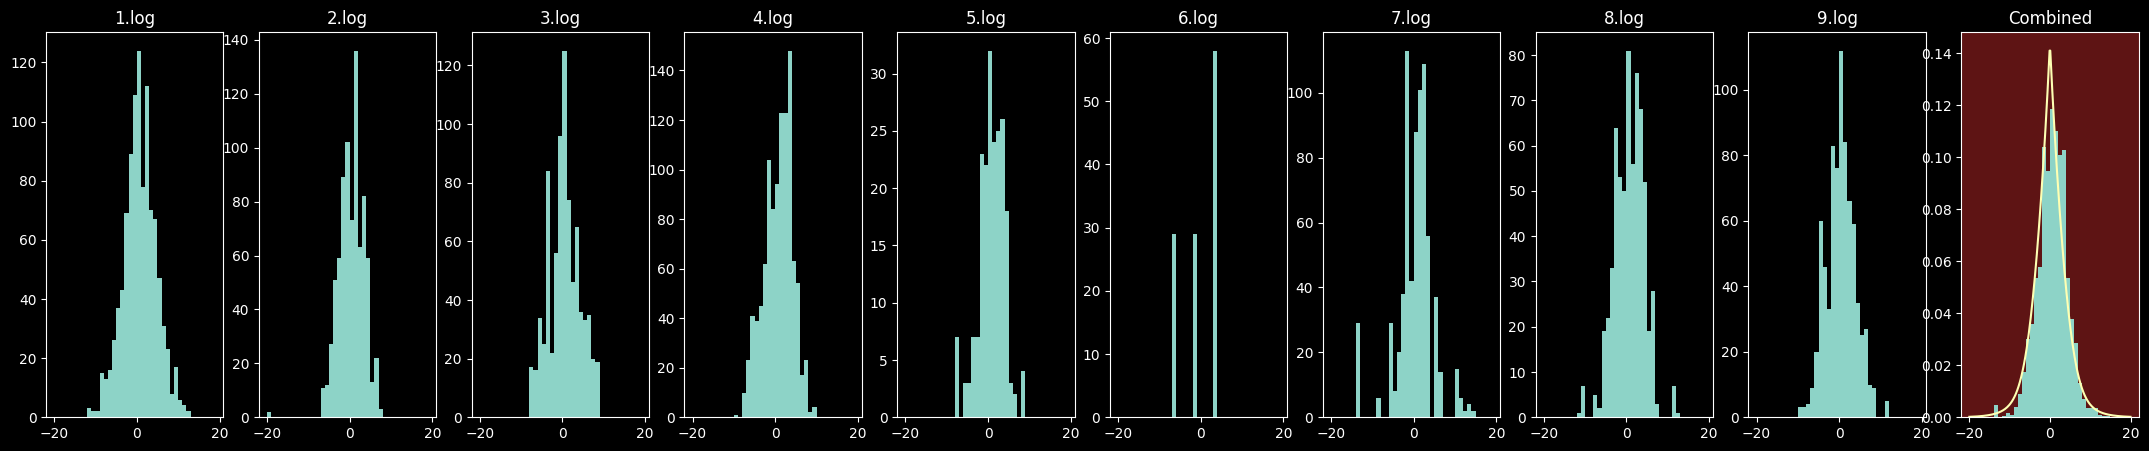

#### 105 to 135 Degrees

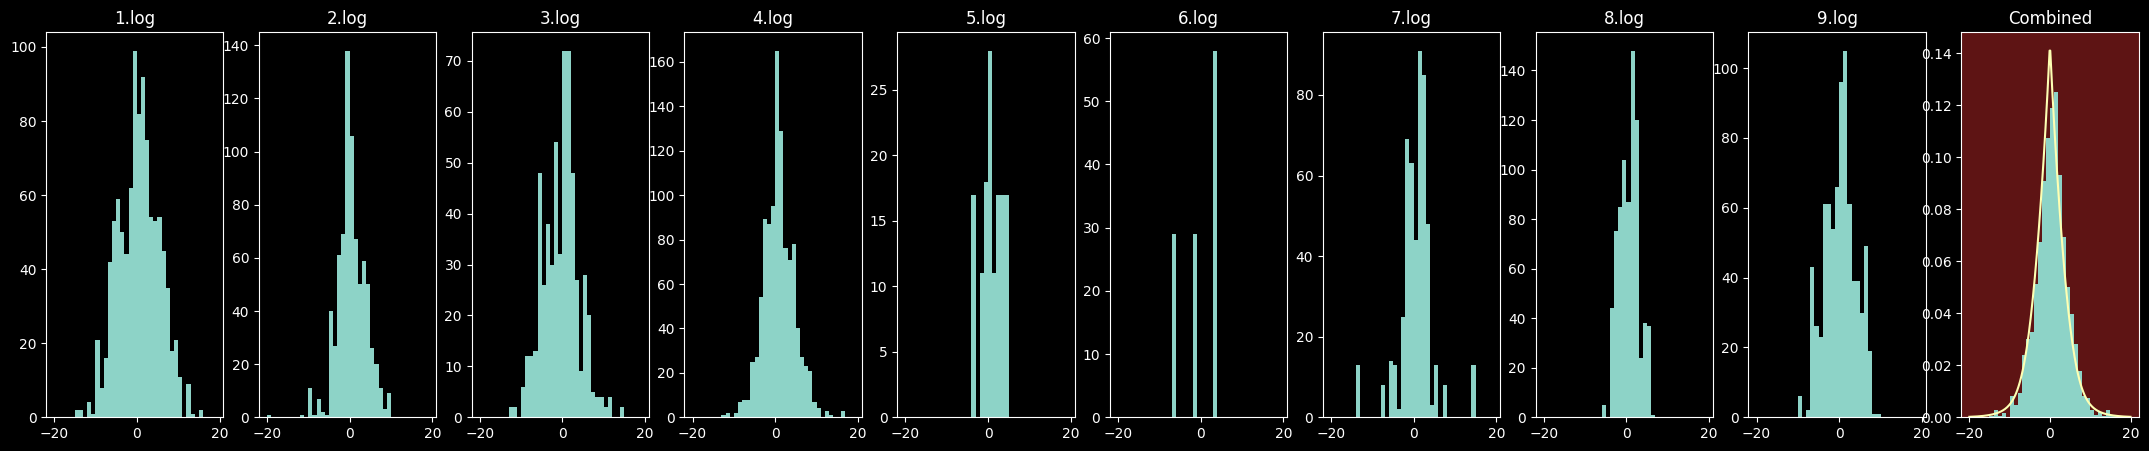

#### 135 to 165 Degrees

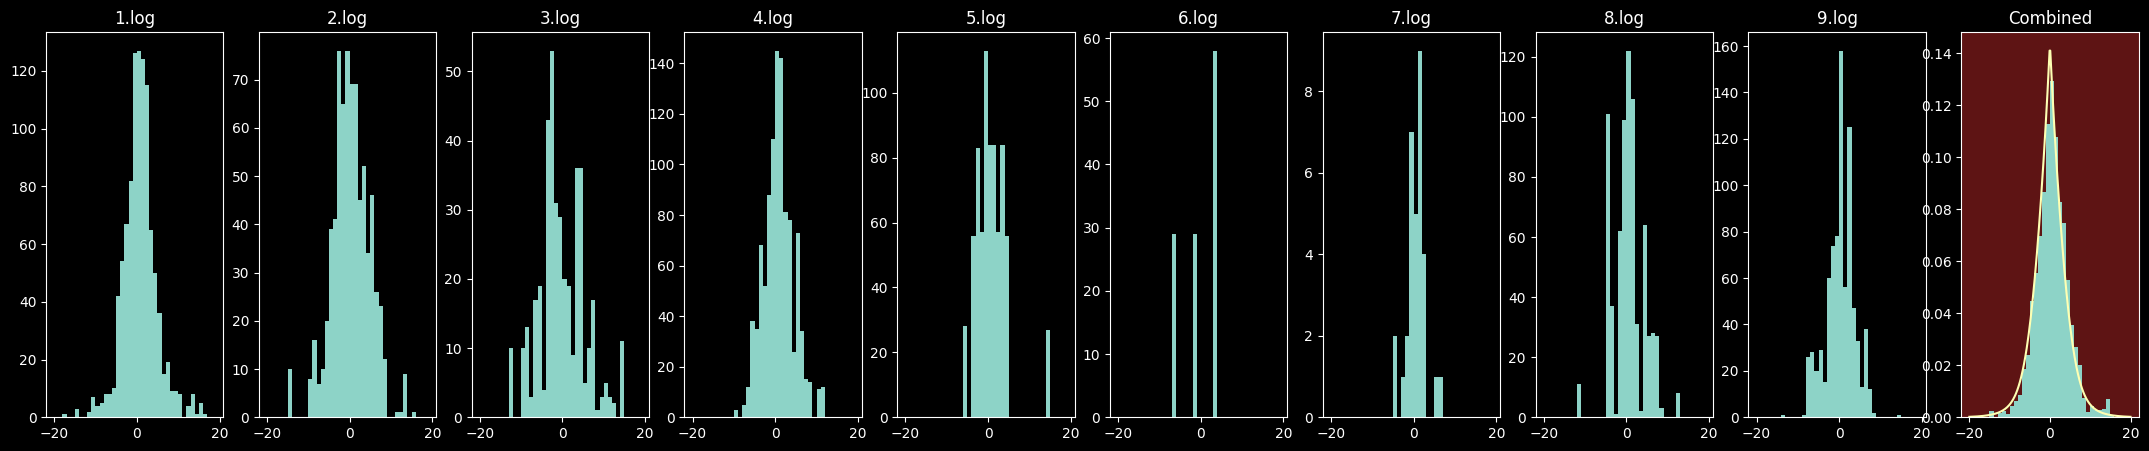

#### 165 to 195 Degrees

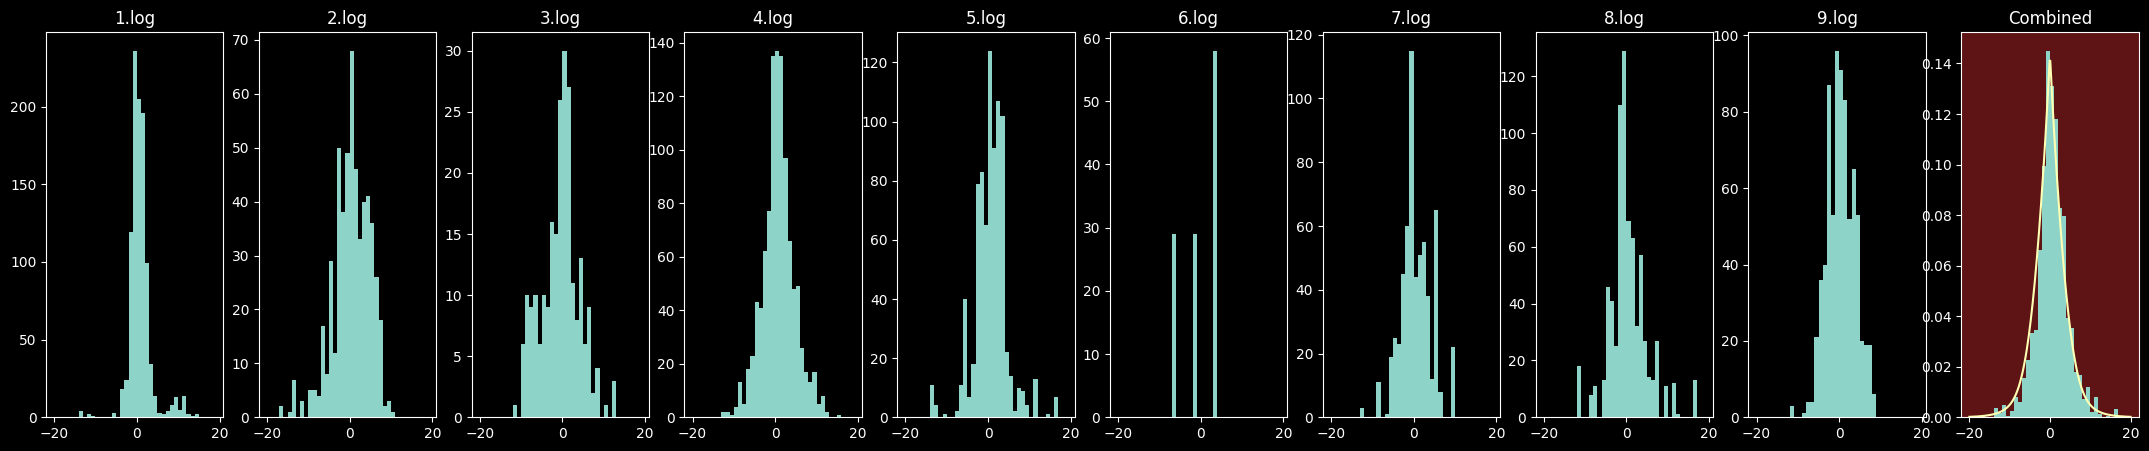

#### 195 to 225 Degrees

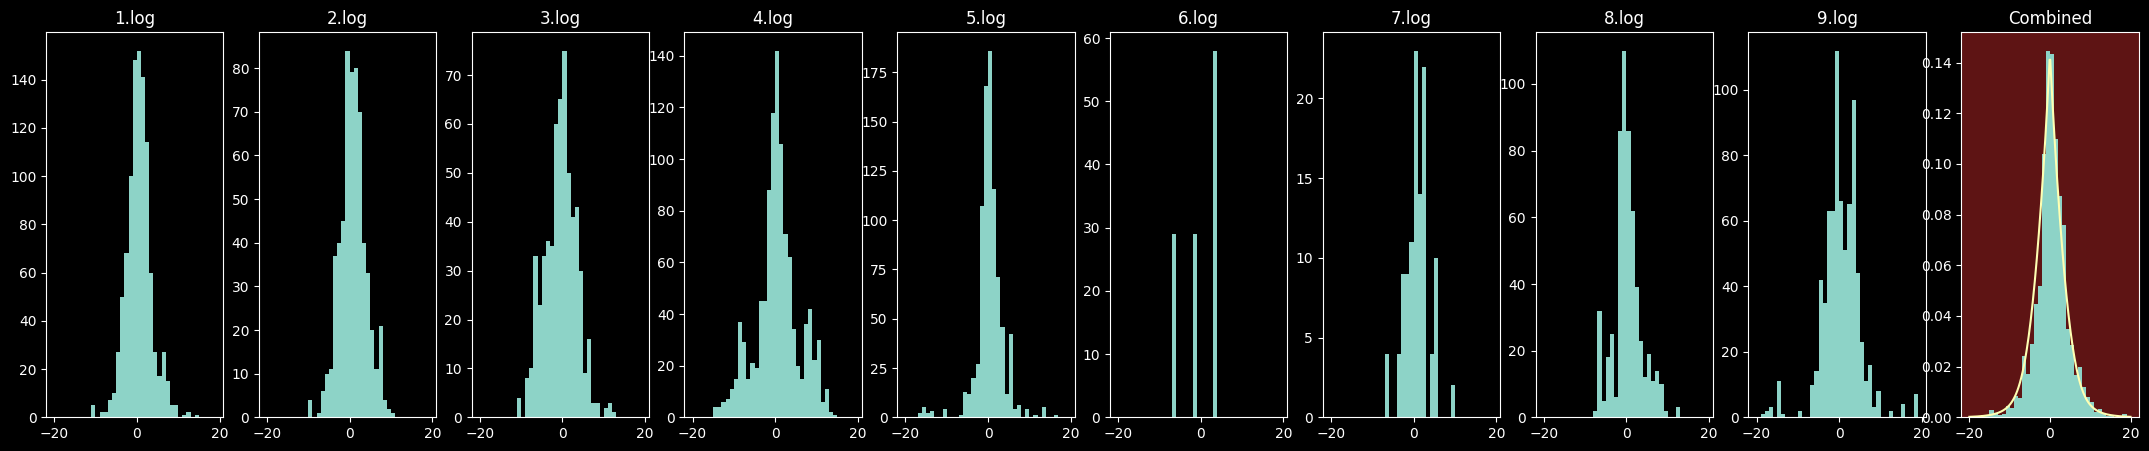

#### 225 to 255 Degrees

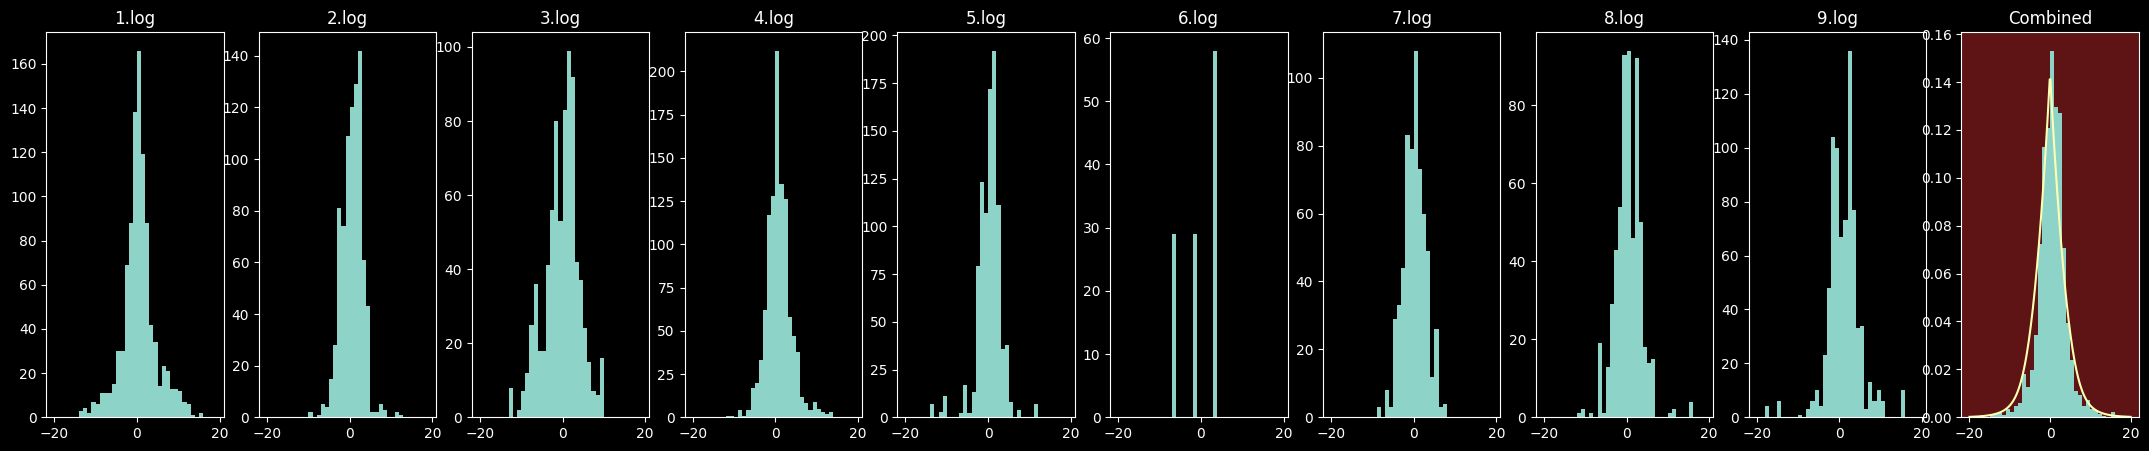

#### 255 to 285 Degrees

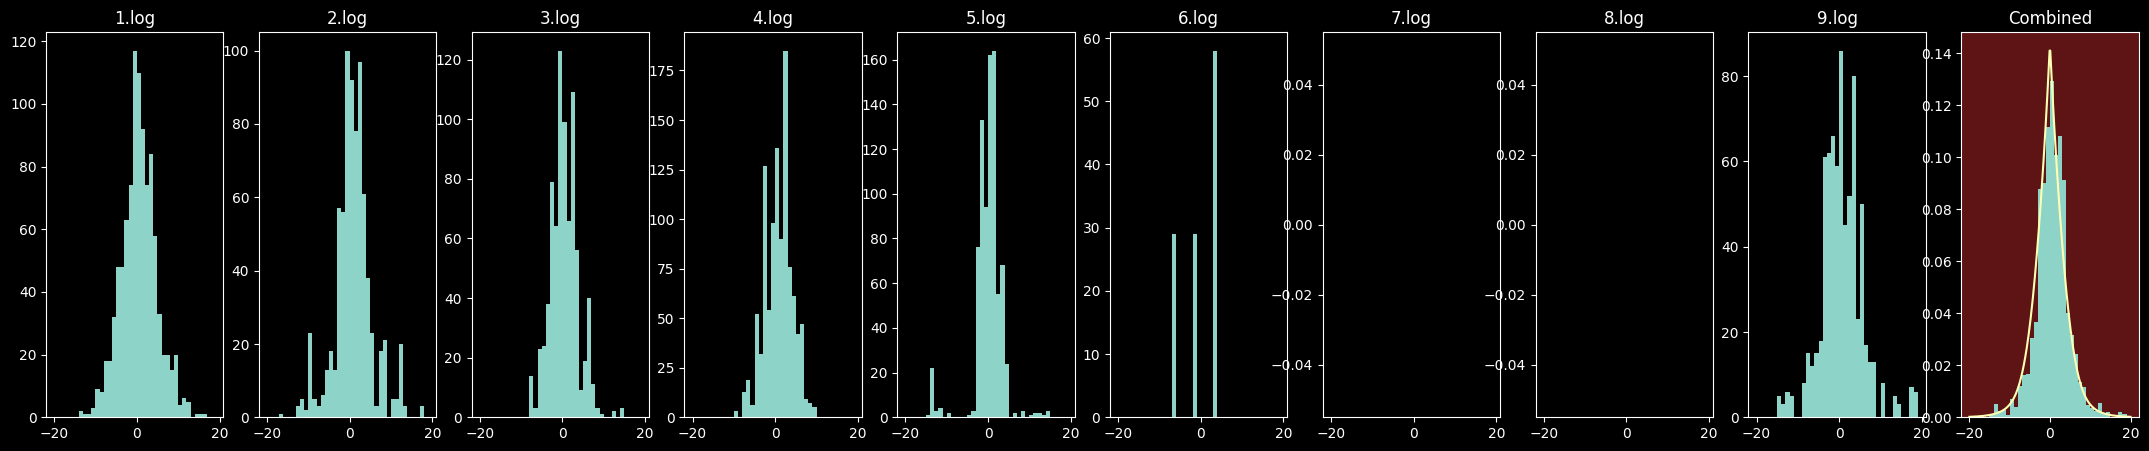

#### 285 to 315 Degrees

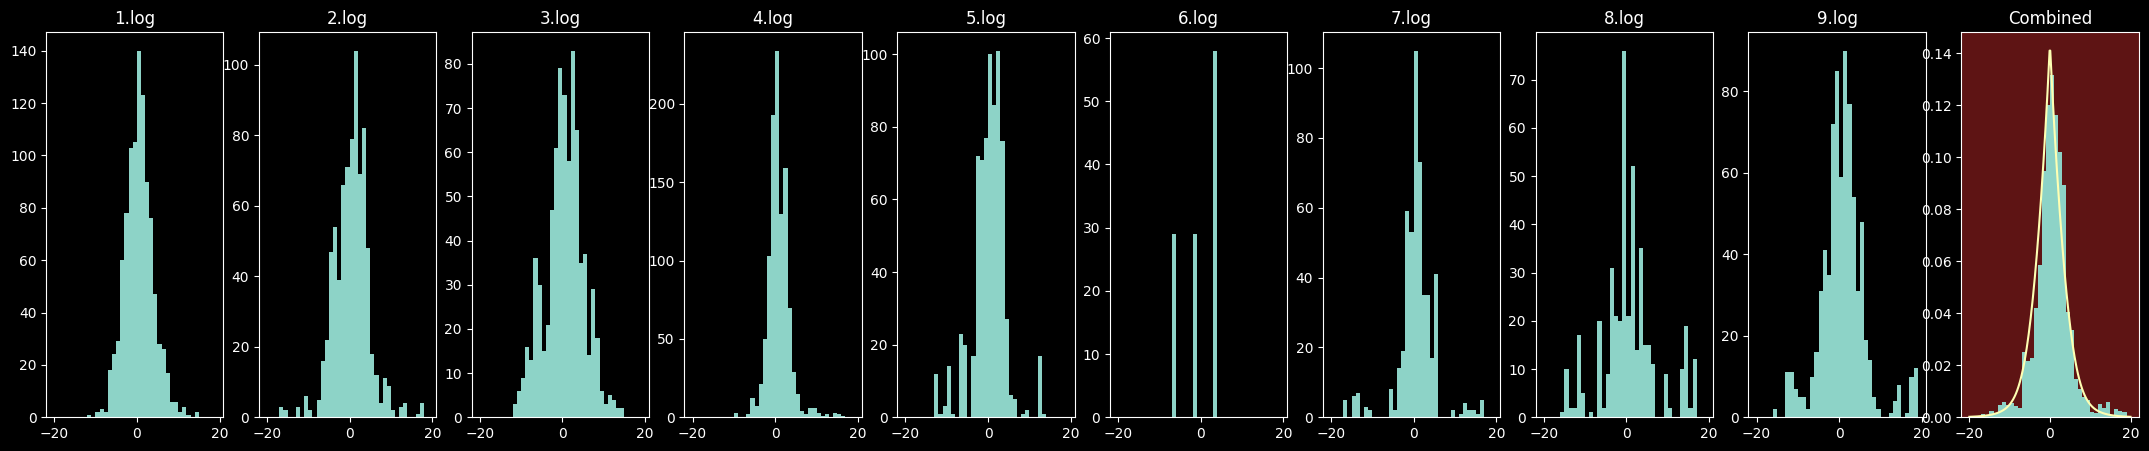

#### 315 to 345 Degrees

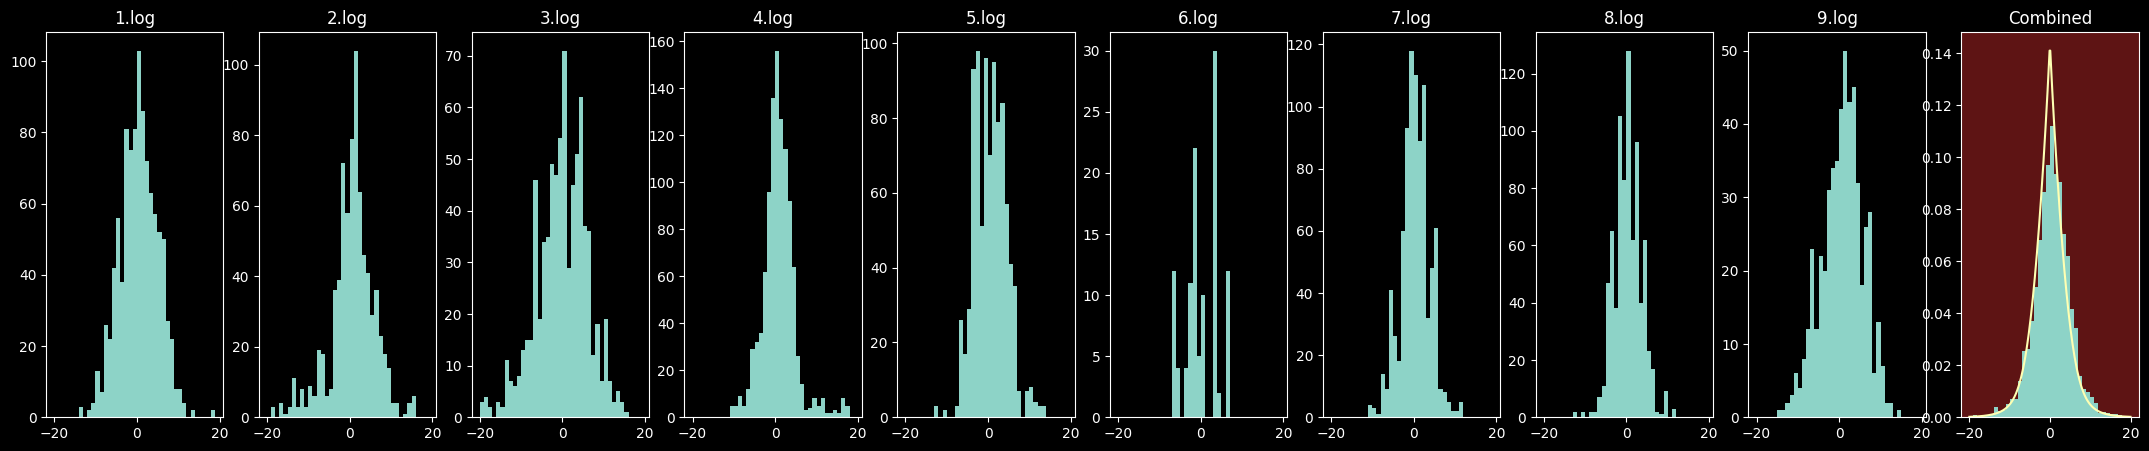

In [40]:
range_trial_rss_diffs_in_blocks(range_logs, 5)

### Ten Packet Differences

The difference is taken between the current packet and the packet at the same gamma in ten transmitter-rotations' time (approximately 20 seconds later). Examine the RSS in 30 degree blocks using histograms, and then all angles combined into one histogram.

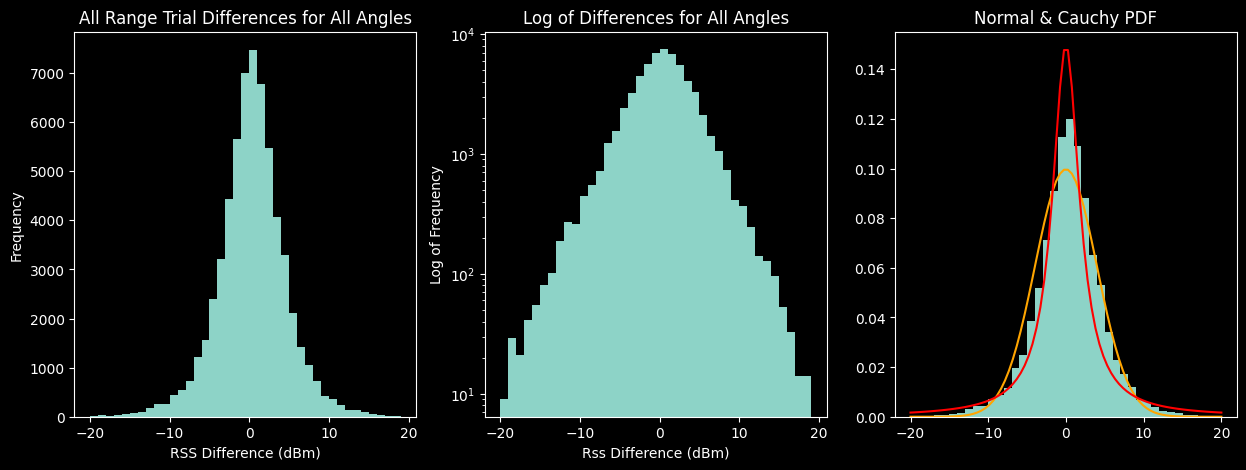

In [66]:
diffs_10 = combined_rss_at_gamma_analysis(range_logs, 10)

In [ ]:
range_trial_rss_diffs_in_blocks(range_logs, 10)

### K-Means

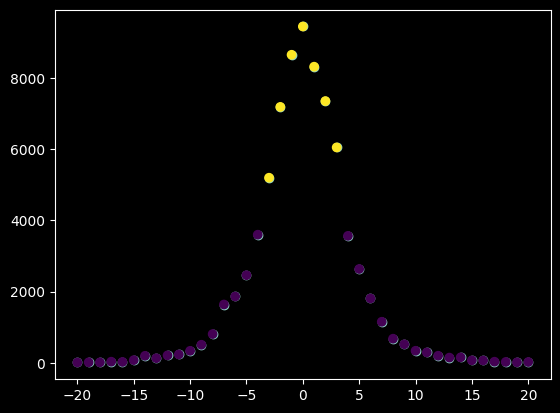

In [13]:
from sklearn.cluster import KMeans

freq_diff = [0] * 41 # [20] is diff of 0
rss = [-20, -19, -18, -17, -16, -15, -14, -13, -12, -11, -10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

for diff in diffs:
    try:
        freq_diff[diff + 20] += 1
    except:
        pass

plt.scatter(rss, freq_diff)

data = list(zip(rss, freq_diff))

kmeans = KMeans(n_clusters=2)
kmeans.fit(np.array(freq_diff).reshape(-1,1))

plt.scatter(rss, freq_diff, c=kmeans.labels_)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (5 chains in 3 jobs)
NUTS: [mean_posterior, std_posterior]


Output()

Sampling 5 chains for 1_000 tune and 10_000 draw iterations (5_000 + 50_000 draws total) took 40 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mean_posterior,0,0,0,0,0,0,54168,38183,1
std_posterior,1,0,1,1,0,0,51769,36854,1


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (5 chains in 3 jobs)
NUTS: [mean_posterior, std_posterior]


Output()

Sampling 5 chains for 1_000 tune and 10_000 draw iterations (5_000 + 50_000 draws total) took 21 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mean_posterior,0,0,0,0,0,0,53206,35240,1
std_posterior,6,0,6,6,0,0,50951,37448,1


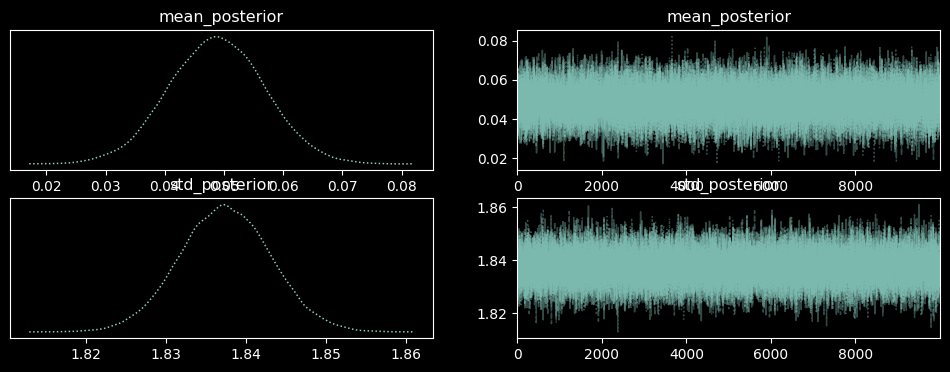

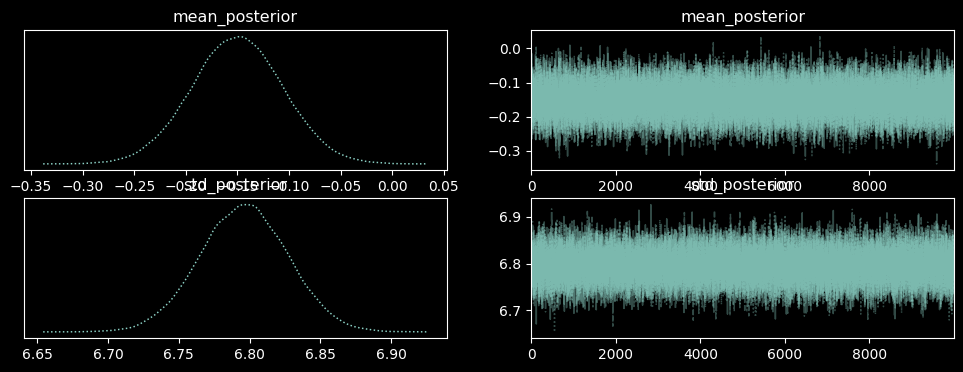

In [15]:
import pymc as pm
import arviz as az

diffs_pink = []

# filter out all "narrow" values
for diff in diffs:
    if -3 <= diff <= 3:
        diffs_pink.append(diff)

bee_wide_pink = pm.Model()

with bee_wide_pink:
    mean_prior = pm.Uniform("mean_posterior", lower=-3, upper=3)
    # mean_prior = pm.Normal("mean_posterior", mu=0, sigma=3)
    # std_prior = pm.HalfNormal("std_posterior", sigma=2)
    std_prior = pm.Uniform("std_posterior", lower=-5, upper=5)

    likelihood = pm.Normal("obs", mu=mean_prior, sigma=std_prior, observed=diffs_pink)

    trace_pink = pm.sample(10_000, chains=5)

az.plot_trace(trace_pink, combined=True)
summary_pink = az.summary(trace_pink, round_to=2)
display(summary_pink)

diffs_pink = []

# filter out all "narrow" values
for diff in diffs:
    if diff < -3 or diff > 3:
        diffs_pink.append(diff)

bee_wide_pink = pm.Model()

with bee_wide_pink:
    mean_prior = pm.Uniform("mean_posterior", lower=-10, upper=10)
    # mean_prior = pm.Normal("mean_posterior", mu=0, sigma=3)
    # std_prior = pm.HalfNormal("std_posterior", sigma=2)
    std_prior = pm.Uniform("std_posterior", lower=-17, upper=17)

    likelihood = pm.Normal("obs", mu=mean_prior, sigma=std_prior, observed=diffs_pink)

    trace_yellow = pm.sample(10_000, chains=5)

az.plot_trace(trace_yellow, combined=True)
summary_yellow = az.summary(trace_yellow, round_to=2)
display(summary_yellow)

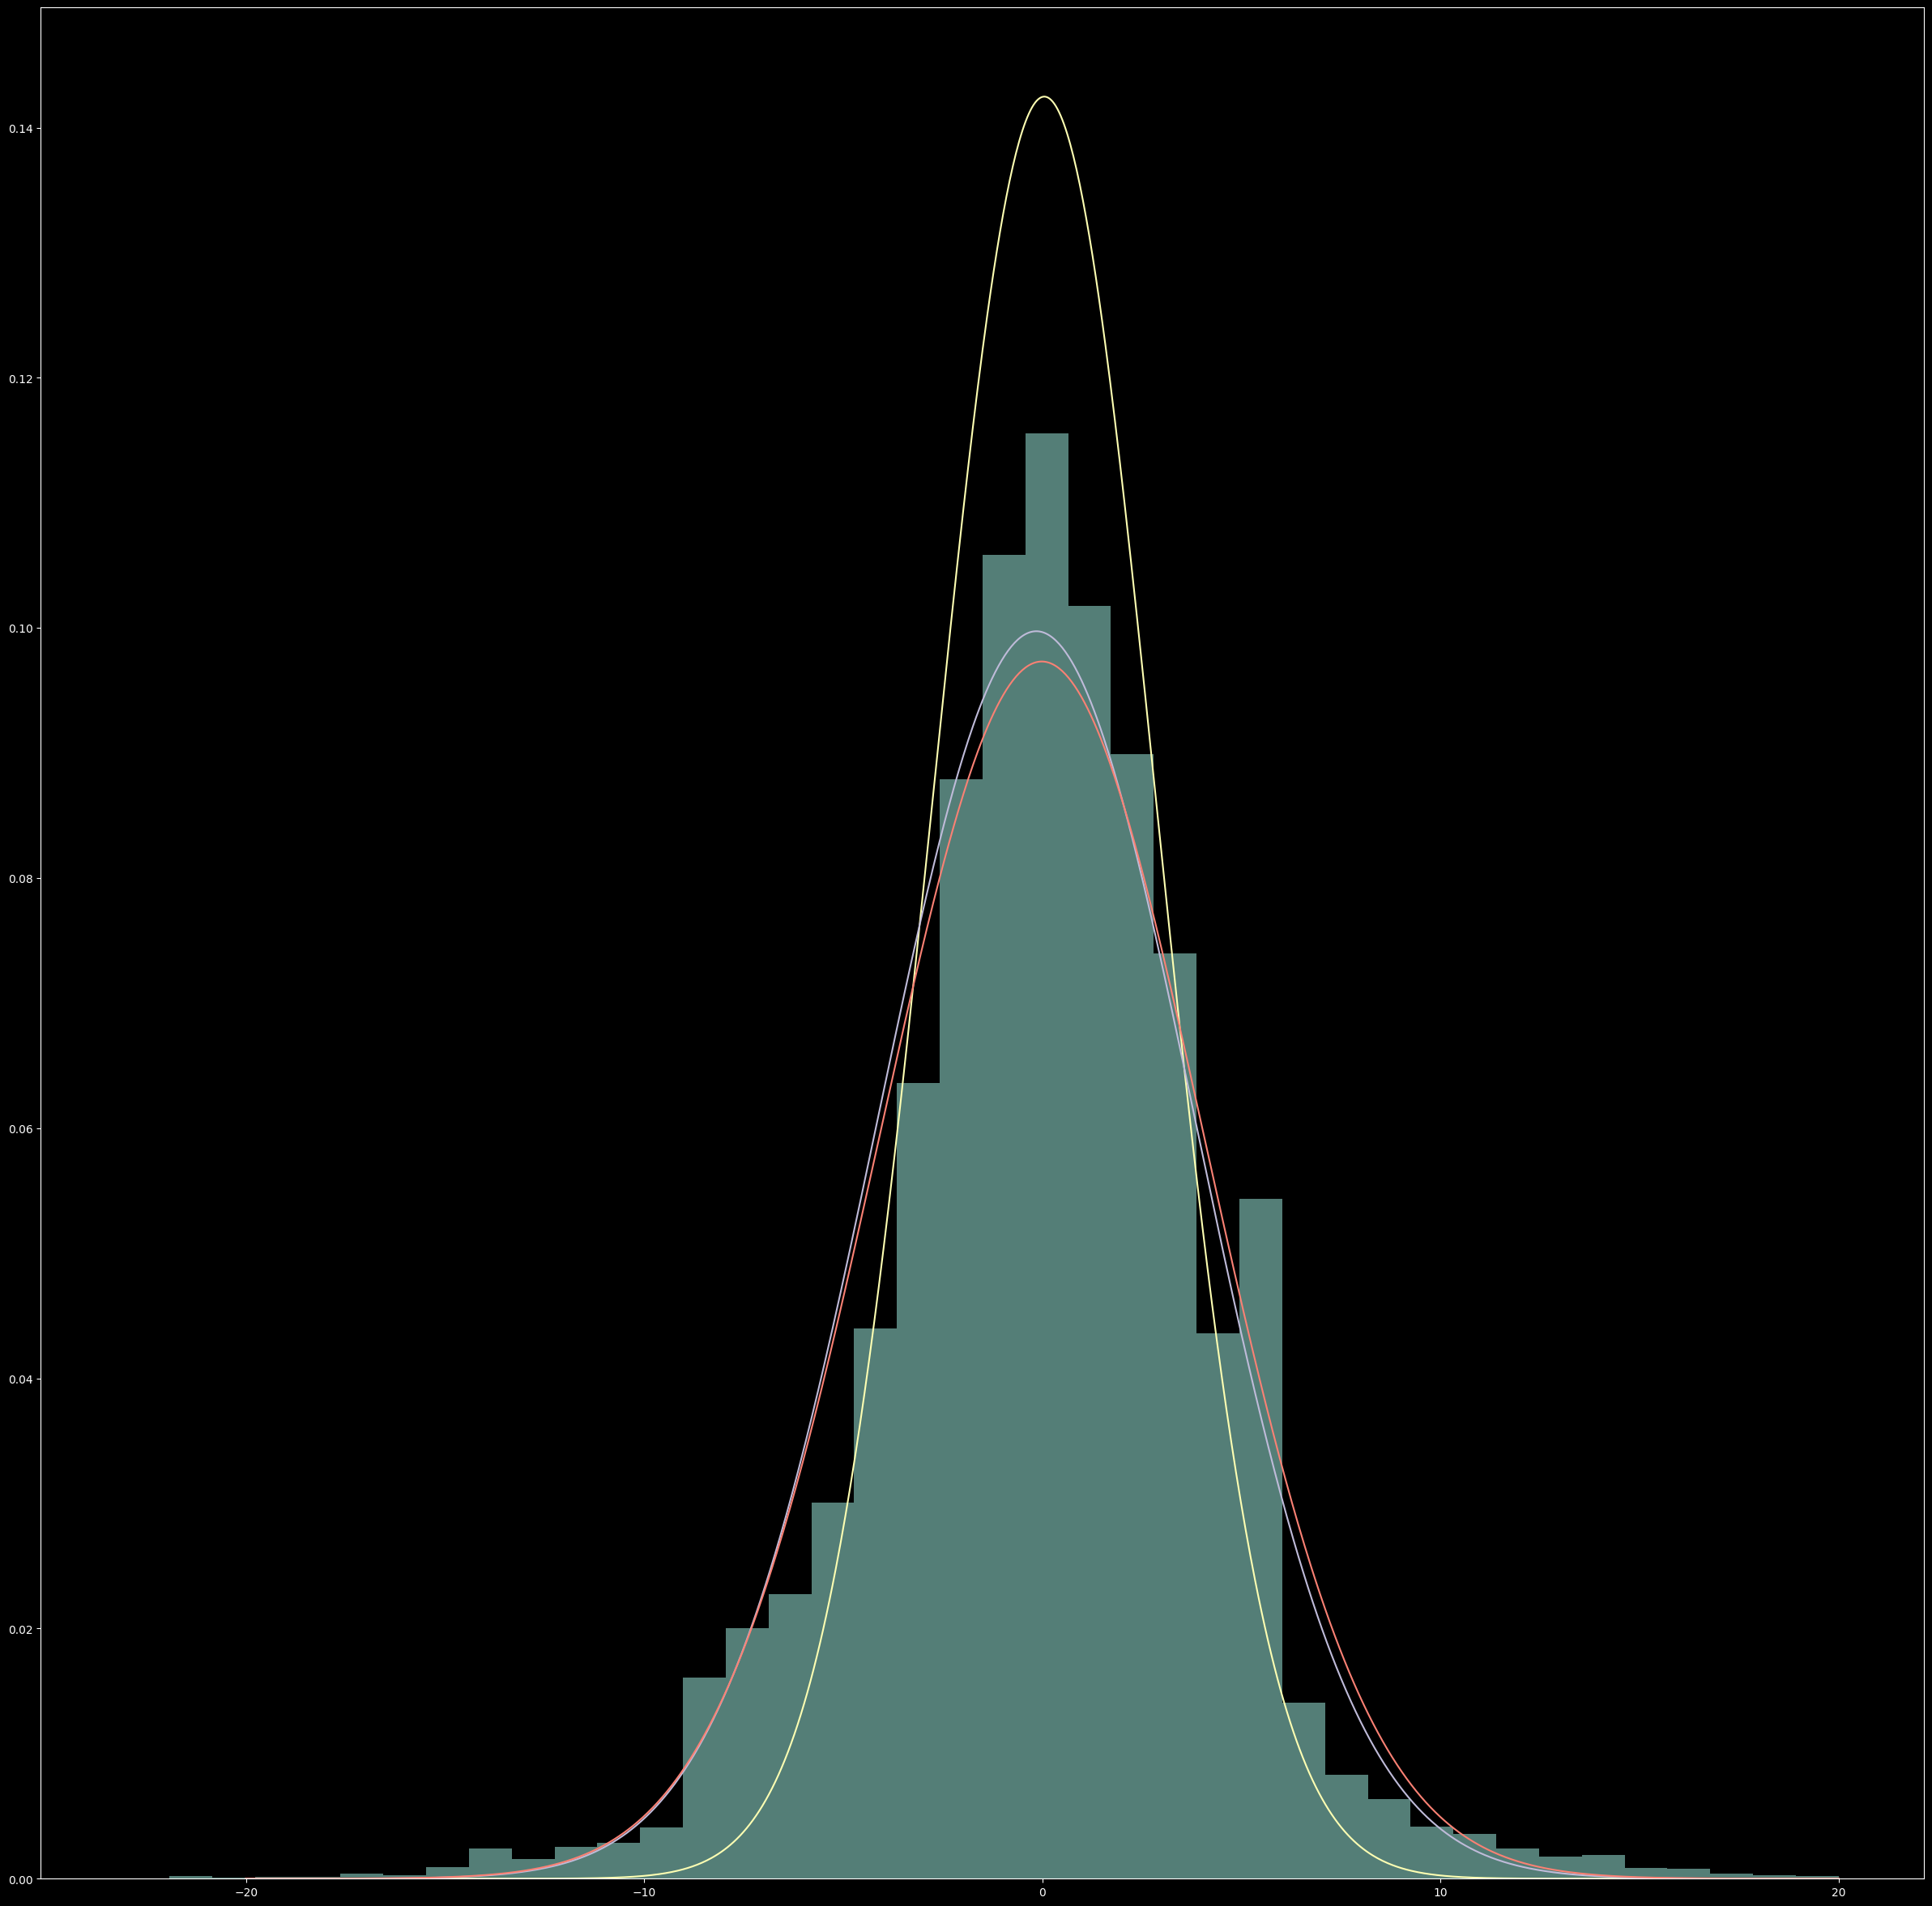

In [34]:
plt.figure(figsize=(30, 30))
plt.hist(diffs, bins=40, alpha=0.6, density=True)

y_all = norm.pdf(x_axis, summary_pink.loc["mean_posterior", "mean"], 2.8)
y_wide = norm.pdf(x_axis, summary_yellow.loc["mean_posterior", "mean"],4.0)

plt.plot(x_axis, y_all)
plt.plot(x_axis, y_wide)

# normal over all diffs
all_mu, all_std = norm.fit(diffs)
all_norm = norm.pdf(x_axis, all_mu, all_std)
plt.plot(x_axis, all_norm)

plt.show()

## Combined Model

Hopefully this automates how to find the parameters of a mixed model.

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [w, mean, sigma]


Output()

Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 967 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


array([[<Axes: title={'center': 'mean'}>,
        <Axes: title={'center': 'mean'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>],
       [<Axes: title={'center': 'w'}>, <Axes: title={'center': 'w'}>]],
      dtype=object)

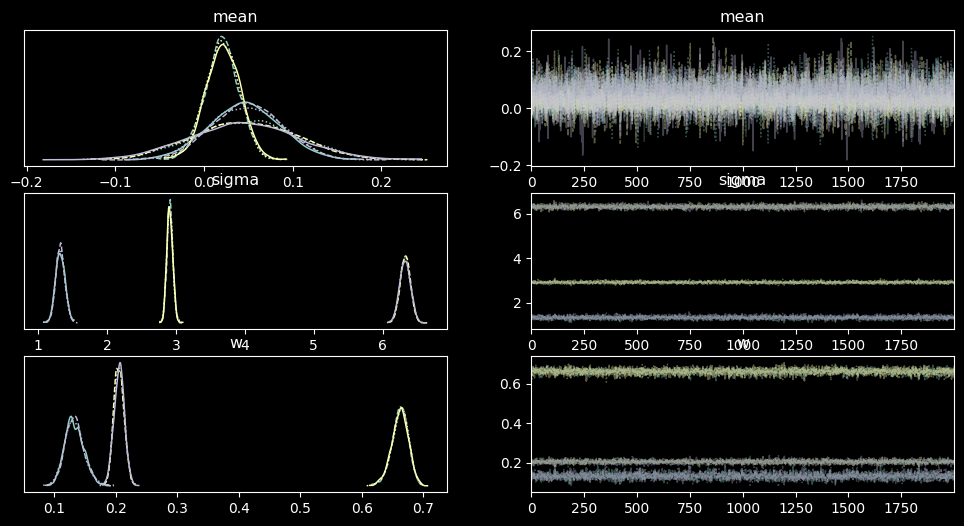

In [20]:
import pymc as pm
import arviz as az

mix_bee_model = pm.Model()

with mix_bee_model:
    # w = pm.Beta("w", alpha=1, beta=1)
    w = pm.Dirichlet("w", a=np.ones(3))
    mean = pm.Normal("mean", mu=0, sigma=1, shape=3)
    # sigma = pm.HalfNormal("sigma", sigma=5, shape=3)
    sigma = pm.Uniform("sigma", lower=1, upper=15, shape=3)

    components = pm.Normal.dist(mu=mean, sigma=sigma, shape=3)

    y = pm.Mixture("y", w=w, comp_dists=components, observed=diffs)

with mix_bee_model:
    trace = pm.sample(2000, tune=1000, return_inferencedata=True)

az.summary(trace)
az.plot_trace(trace)

In [12]:
display(az.summary(trace))

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mean[0],0.038,0.036,-0.027,0.109,0.007,0.003,31.0,1019.0,1.07
mean[1],0.045,0.058,-0.061,0.154,0.001,0.001,4231.0,3827.0,1.00
mean[2],0.030,0.031,-0.024,0.096,0.007,0.007,27.0,35.0,1.11
sigma[0],1.851,0.751,1.210,2.964,0.432,0.152,5.0,37.0,1.66
sigma[1],6.323,0.074,6.189,6.466,0.001,0.001,3115.0,3542.0,1.00
sigma[2],2.380,0.752,1.243,2.995,0.432,0.153,5.0,38.0,1.66
w[0],0.309,0.250,0.108,0.679,0.144,0.051,5.0,35.0,1.67
w[1],0.206,0.008,0.189,0.220,0.000,0.000,2632.0,3472.0,1.00
w[2],0.485,0.250,0.115,0.686,0.144,0.051,5.0,36.0,1.66


In [21]:
display(az.summary(trace))

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mean[0],0.038,0.044,-0.035,0.137,0.007,0.007,46.0,108.0,1.10
mean[1],0.030,0.039,-0.044,0.116,0.006,0.011,78.0,34.0,1.18
mean[2],0.047,0.049,-0.041,0.143,0.001,0.005,3756.0,379.0,1.03
sigma[0],3.521,2.089,1.230,6.425,1.203,0.426,4.0,35.0,2.37
sigma[1],4.051,1.612,2.831,6.409,0.929,0.329,5.0,32.0,1.66
sigma[2],2.991,2.360,1.207,6.425,1.359,0.481,5.0,37.0,1.66
w[0],0.333,0.235,0.114,0.680,0.135,0.048,4.0,32.0,2.37
w[1],0.510,0.216,0.194,0.683,0.124,0.044,5.0,35.0,1.66
w[2],0.157,0.037,0.110,0.219,0.020,0.006,5.0,38.0,1.66


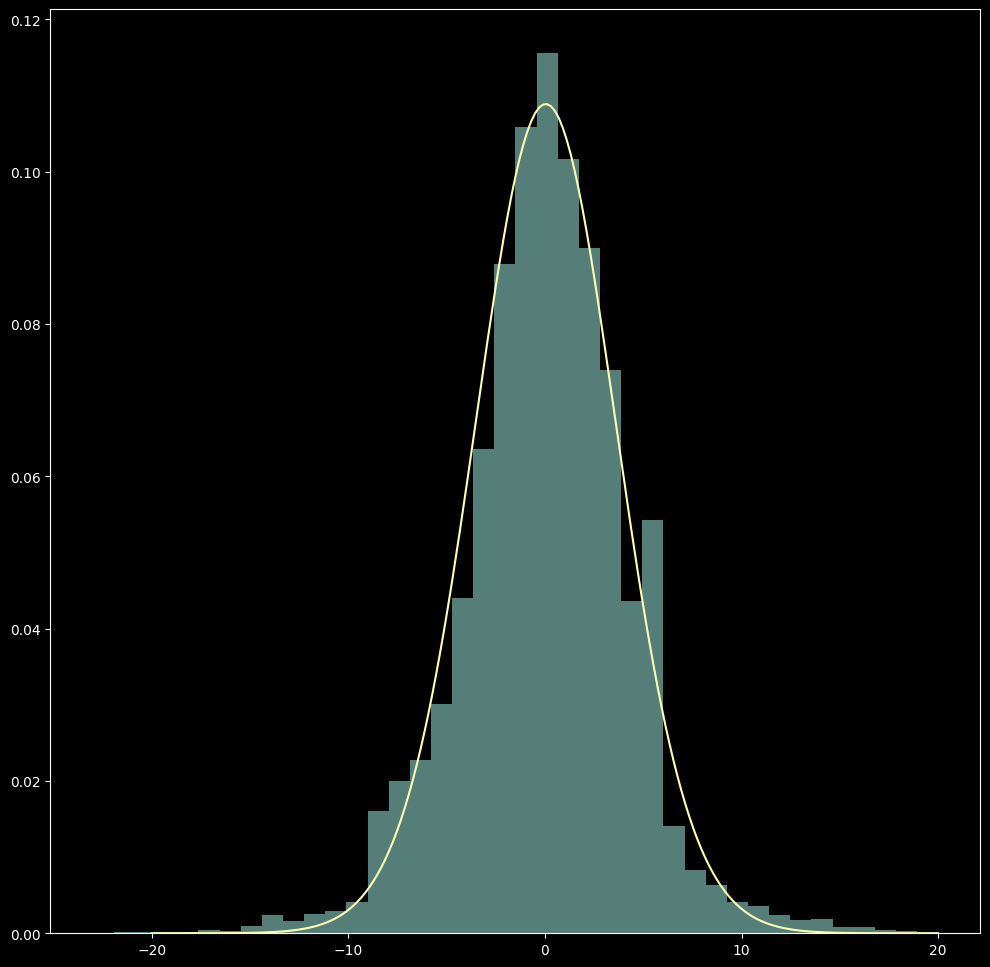

In [57]:
plt.figure(figsize=(30, 30))
plt.hist(diffs_5, bins=40, alpha=0.6, density=True)
x_axis = np.linspace(-20, 20, 40*5)
y1 = norm.pdf(x_axis, 0.038, 3.521)
y2 = norm.pdf(x_axis, 0.030, 4.051)
y3 = norm.pdf(x_axis, 0.047, 2.991)
# y4 = norm.pdf(x_axis, 0, 20)
# y5 = cauchy.pdf(x_axis, scale=2.183)

mix = 0.333 * y1 + 0.51 * y2 + 0.157 * y3

# plt.plot(x_axis, y1)
# plt.plot(x_axis, y2)
# plt.plot(x_axis, y3)
# plt.plot(x_axis, y4)
# plt.plot(x_axis, y5)

plt.show()

## Cauchy Distribution

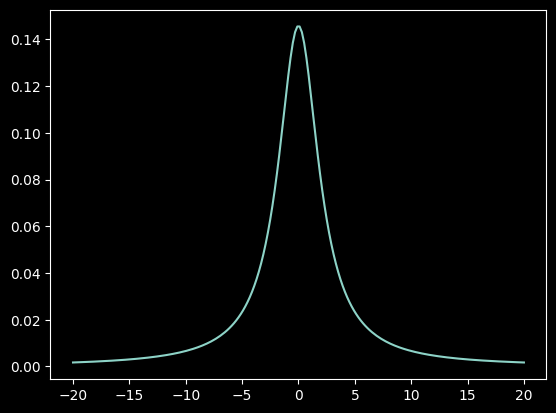

In [16]:
from scipy.stats import cauchy

x_axis = np.linspace(-20, 20, 40*5)
y_e1 = cauchy.pdf(x_axis, scale=2.183)

plt.plot(x_axis, y_e1)
plt.show()

In [10]:
import pymc as pm
import arviz as az

def learn_cauchy(rss_diffs :list[int]):
    """
    Learns the parameter beta of the cauchy distribution
    and then plots it overtop of the histogram
    """
    with pm.Model():
        alpha = 0
        beta = pm.HalfNormal("beta", sigma=2)

        obs = pm.Cauchy("obs", alpha=alpha, beta=beta, observed=rss_diffs)

        trace = pm.sample(2000, tune=1000)

    summary = az.summary(trace)
    display(az.summary(trace))

    # plot PDF over histogram
    x_vals = np.linspace(min(rss_diffs), max(rss_diffs))
    plt.hist(rss_diffs, bins=x_vals, alpha=0.6, density=True)
    plt.plot(x_vals, cauchy.pdf(x_vals, scale=summary.loc["beta", "mean"]))

    plt.plot(x_vals, norm.pdf(x_vals, 0, 3.5))

    plt.show()

/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [beta]


Output()

Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 19 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta,1.854,0.008,1.839,1.87,0.0,0.0,2683.0,3732.0,1.0


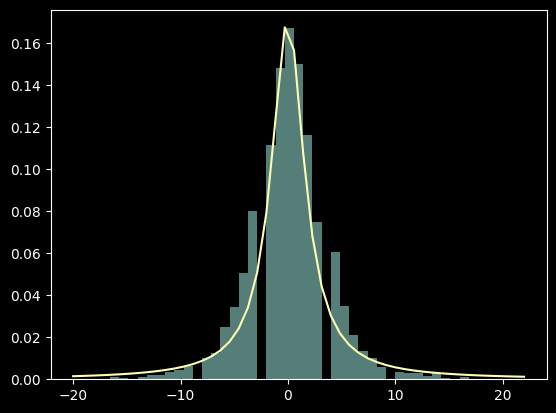

In [93]:
learn_cauchy(diffs_0)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [beta]


Output()

Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 18 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta,2.123,0.01,2.105,2.143,0.0,0.0,2689.0,3981.0,1.0


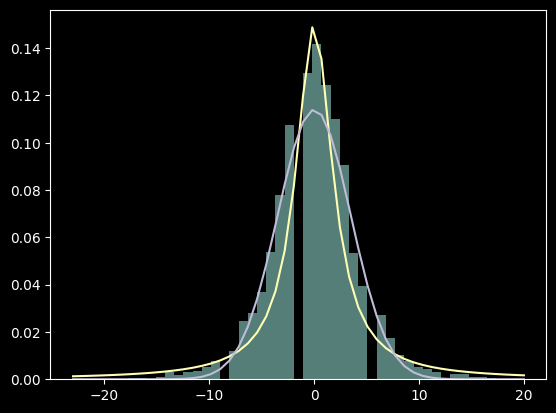

In [101]:
learn_cauchy(diffs_5)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [beta]


Output()

Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 15 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta,2.212,0.011,2.19,2.232,0.0,0.0,2712.0,4259.0,1.0


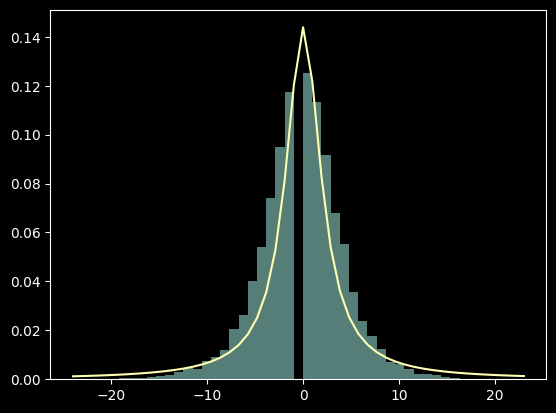

In [94]:
learn_cauchy(diffs_10)

## Cauchy and Normal Mixture Model

In [11]:
with pm.Model():
    # w = pm.Beta("w", alpha=1, beta=1)
    w = pm.Dirichlet("w", a=np.array([1, 1]))
    sigma = pm.HalfNormal("sigma", sigma=4)
    beta = pm.HalfNormal("beta", sigma=4)

    normal_comp = pm.Normal.dist(mu=0, sigma=sigma)
    cauchy_comp = pm.Cauchy.dist(alpha=0, beta=beta)

    obs = pm.Mixture(
        "obs",
        w=w, #[w, 1 - w],
        comp_dists=[normal_comp, cauchy_comp],
        observed=diffs_5
    )

    trace = pm.sample(1000, tune=2000, target_accept=0.9, return_inferencedata=True)

display(az.summary(trace))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [w, sigma, beta]
/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Output()

Sampling 3 chains for 2_000 tune and 1_000 draw iterations (6_000 + 3_000 draws total) took 1265 seconds.
There were 1567 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta,0.412,0.583,0.000,1.265,0.335,0.119,5.0,37.0,1.68
sigma,4.246,0.189,3.958,4.401,0.108,0.038,5.0,42.0,1.67
w[0],0.851,0.034,0.798,0.879,0.020,0.007,5.0,40.0,1.69
w[1],0.149,0.034,0.121,0.202,0.020,0.007,5.0,40.0,1.69


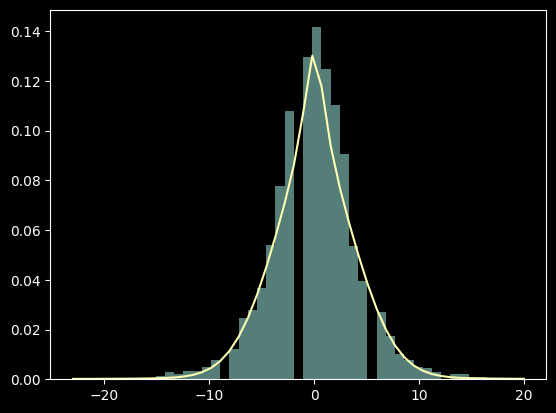

In [106]:
# plot PDF over histogram
x_vals = np.linspace(min(diffs_5), max(diffs_5))
plt.hist(diffs_5, bins=x_vals, alpha=0.6, density=True)

w = 0.803
c = cauchy.pdf(x_vals, scale=1.234)
n = norm.pdf(x_vals, 0, 3.980)

mix = w * n + (1 - w) * c

plt.plot(x_vals, mix)
plt.show()

#### Manual Parameter Experimentation

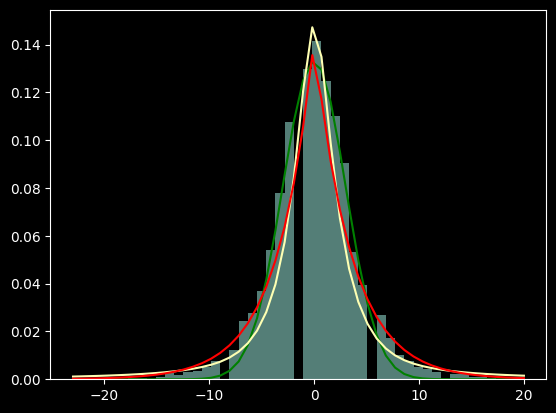

In [25]:
from scipy.stats import laplace

x_vals = np.linspace(min(diffs_5), max(diffs_5))
plt.hist(diffs_5, bins=x_vals, alpha=0.6, density=True)

c = cauchy.pdf(x_vals, scale=2.123)
n = norm.pdf(x_vals, 0, 3)
l = laplace.pdf(x_vals, loc=0, scale=3.5)

mix = 0.1 * n + 0.9 * c
# mix = (1 - 10**-10) * n + 10**-10 * c

# plt.plot(x_vals, c, 'red')
plt.plot(x_vals, n, 'green')
plt.plot(x_vals, mix)
plt.plot(x_vals, l, 'red')
plt.show()

### Laplace??

In [17]:
import arviz as az
import pymc as pm

def learn_laplace(rss_diffs :list[int]):
    with pm.Model():
        mu = 0
        std = pm.HalfNormal("std", sigma=2)

        obs = pm.Laplace("obs", mu=mu, b=std, observed=rss_diffs)

        trace = pm.sample(2000, tune=1000)

    summary = az.summary(trace)
    display(az.summary(trace))

    # plot PDF over histogram
    x_vals = np.linspace(min(rss_diffs), max(rss_diffs))
    plt.hist(rss_diffs, bins=x_vals, alpha=0.6, density=True)
    plt.plot(x_vals, laplace.pdf(x_vals, loc=0, scale=summary.loc["std", "mean"]))

    # plt.plot(x_vals, norm.pdf(x_vals, 0, 3.5))

    plt.show()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [std]


Output()

Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 4 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
std,3.01,0.011,2.99,3.03,0.0,0.0,2598.0,4515.0,1.0


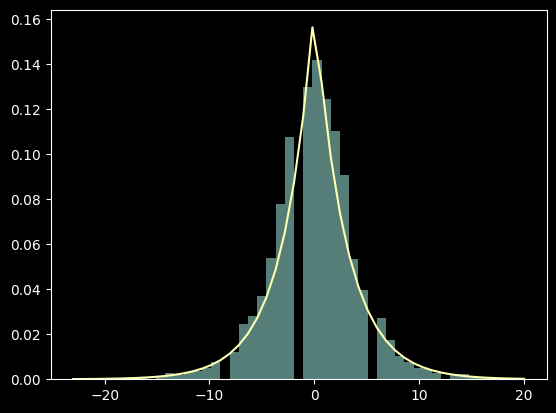

In [18]:
learn_laplace(diffs_5)

#### Laplace and Normal Mixture

In [47]:
import scipy
import pymc as pm
import arviz as az

def learn_laplace_norm_mix(rss_diffs :list[int]):
    with pm.Model():
        w = pm.Dirichlet("w", a=np.array([1, 1]))
        sigma = pm.Normal("sigma", mu=3, sigma=2)
        b = pm.Uniform("b", lower=0, upper=5)

        normal = pm.Normal.dist(mu=0, sigma=sigma)
        laplace = pm.Laplace.dist(mu=0, b=b)

        obs = pm.Mixture("obs", w=w, comp_dists=[normal, laplace], observed=rss_diffs)

        trace = pm.sample(3000)

    summary = az.summary(trace)
    display(az.summary(trace))

    # plot PDF over histogram
    x_vals = np.linspace(min(rss_diffs), max(rss_diffs))
    l = scipy.stats.laplace.pdf(x_vals, 0, summary.loc["b", "mean"])
    n = norm.pdf(x_vals, 0, summary.loc["sigma", "mean"])

    mix = summary.loc["w[0]", "mean"] * n + summary.loc["w[1]", "mean"] * l

    plt.hist(rss_diffs, bins=x_vals, alpha=0.6, density=True)
    plt.plot(x_vals, mix)
    plt.show()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [w, sigma, b]


Output()

Sampling 3 chains for 1_000 tune and 3_000 draw iterations (3_000 + 9_000 draws total) took 186 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
b,3.139,0.025,3.092,3.187,0.000,0.0,4219.0,4795.0,1.0
sigma,3.464,0.042,3.384,3.543,0.001,0.0,4336.0,5236.0,1.0
w[0],0.351,0.013,0.325,0.375,0.000,0.0,5051.0,5388.0,1.0
w[1],0.649,0.013,0.625,0.675,0.000,0.0,5051.0,5388.0,1.0


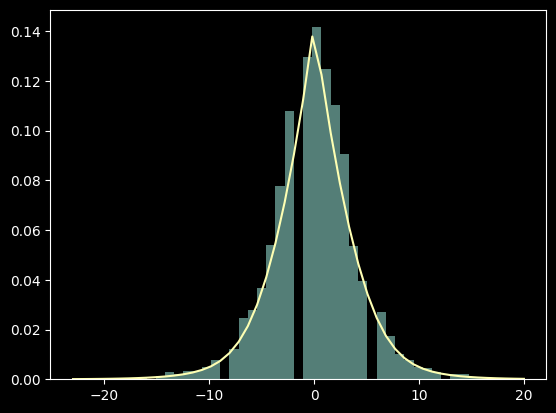

In [48]:
learn_laplace_norm_mix(diffs_5)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [w, sigma, b]


Output()

Sampling 3 chains for 1_000 tune and 3_000 draw iterations (3_000 + 9_000 draws total) took 259 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
b,2.997,0.023,2.956,3.041,0.0,0.0,4247.0,4529.0,1.0
sigma,2.913,0.034,2.846,2.976,0.0,0.0,4746.0,5860.0,1.0
w[0],0.303,0.013,0.278,0.328,0.0,0.0,4772.0,5159.0,1.0
w[1],0.697,0.013,0.672,0.722,0.0,0.0,4772.0,5159.0,1.0


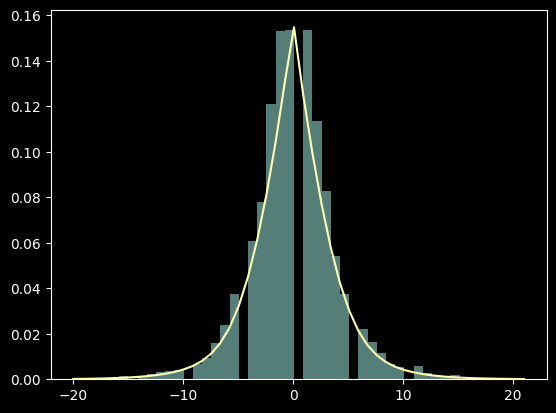

In [51]:
learn_laplace_norm_mix(diffs_2)